# Holistic Data Preparer

## Customer Credit Risk Dataset

---

### Project Overview

In this project, I am working with a customer credit risk dataset from a fictional fintech company.

The main objective is to prepare the dataset for a future Machine Learning model that can predict whether a customer is likely to default on a loan.

Before building a Machine Learning model, I need to make sure that the data is clean, consistent and in a format that a model can actually work with.

I will therefore work through the complete preprocessing process, including:

- Data understanding
- Data quality checking
- Missing value treatment
- Outlier detection and treatment
- Date feature extraction
- Categorical encoding
- Numerical binning
- Feature scaling
- Data transformation
- Feature construction
- Final preprocessing using a ColumnTransformer and Pipeline

The final output will be a cleaned and transformed dataset that is ready for future Machine Learning modelling.

## Business Problem

The company has provided a Customer Credit Risk dataset collected from different sources.

The business wants to eventually build a Machine Learning model that can predict whether a customer is likely to default on a loan.

However, the raw data cannot be directly given to a Machine Learning model because it contains different types of variables, missing values, outliers, categorical information, dates and numerical variables with very different scales.

My job as a Junior Data Scientist is therefore to prepare this data before modelling.

The target variable is:

- `default_flag = 0` → No Default
- `default_flag = 1` → Default

I will focus on data preprocessing and feature engineering rather than building the final Machine Learning model.

## Project Objectives

The main objectives of this project are:

1. Understand the structure and quality of the customer dataset.
2. Identify and handle missing values.
3. Detect and treat numerical outliers.
4. Convert and extract useful information from date variables.
5. Encode categorical variables into numerical form.
6. Apply different numerical binning techniques.
7. Compare different feature scaling methods.
8. Apply mathematical transformations to skewed variables.
9. Construct new features that may be useful for credit risk analysis.
10. Build a final preprocessing workflow using ColumnTransformer and Pipeline.
11. Validate the final dataset.
12. Export the cleaned dataset for future Machine Learning modelling.

In [1]:
# Main libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Statistical tools
from scipy.stats import skew, zscore
from scipy.stats.mstats import winsorize

# Missing value handling
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# Encoding
from sklearn.preprocessing import (
    OrdinalEncoder,
    LabelEncoder,
    OneHotEncoder
)

# Scaling
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    MaxAbsScaler,
    RobustScaler
)

# Binning and binarization
from sklearn.preprocessing import KBinsDiscretizer, Binarizer

# Transformations
from sklearn.preprocessing import FunctionTransformer, PowerTransformer

# ColumnTransformer and Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Database and JSON handling
import json
import sqlite3

# Reproducibility
np.random.seed(42)

print("Libraries imported successfully.")

Libraries imported successfully.


## Part A — Conceptual Foundation

### 1. What is Data Analysis?

Data Analysis is the process of examining data to understand what is happening in a dataset and to find useful information from it.

In a typical project, I would start by looking at:

- The number of rows and columns
- The data types
- Missing values
- Duplicate records
- Unusual values
- Distributions of numerical variables
- Categories in categorical variables
- Relationships between variables

The purpose is not simply to generate statistics. The main goal is to turn raw data into information that can support a decision or solve a business problem.

For this project, data analysis helps me understand the customers before I start applying preprocessing techniques.

### 2. How to Plan a Data Science Project

A Data Science project should be planned before jumping straight into coding.

My general workflow for this project is:

1. Understand the business problem.
2. Understand what the target variable represents.
3. Collect the required data.
4. Explore the dataset.
5. Check data quality.
6. Clean missing and incorrect values.
7. Detect and handle outliers.
8. Engineer useful features.
9. Encode categorical variables.
10. Scale and transform numerical variables where required.
11. Validate the final dataset.
12. Prepare the dataset for Machine Learning.

The important point is that preprocessing should be based on what I find in the data rather than applying every technique blindly.

### 3. How to Frame a Machine Learning Problem

For this project, the business question can be converted into a Machine Learning problem.

### Business Question

Can we predict whether a customer is likely to default on a loan?

### Machine Learning Problem

This is a **binary classification problem** because the target has two possible outcomes:

- `0` → No Default
- `1` → Default

### Target Variable

The target variable is:

`default_flag`

### Possible Input Features

Some of the features that may be useful include:

- Age
- Employment type
- Annual income
- Loan amount
- Loan purpose
- Credit score
- Repayment history
- Transaction count
- Spending ratio
- Information extracted from the joining date

I will not use `customer_id` as a predictive feature because it is an identifier rather than a meaningful customer characteristic.

The purpose of this project is mainly to prepare these features correctly so they can be used by a future Machine Learning model.

### 4. Understanding Tensors

A tensor is a general way of representing numerical data across multiple dimensions.

A useful way to think about tensors is:

- A scalar is a 0-dimensional tensor.
- A vector is a 1-dimensional tensor.
- A matrix is a 2-dimensional tensor.
- A higher-dimensional array is a tensor with 3 or more dimensions.

For example:

A single number:

`25`

can be represented as a scalar.

A list of numbers:

`[10, 20, 30]`

can be represented as a vector.

A table:

```text
10 20 30
40 50 60

In [2]:
# A scalar contains a single value

scalar = np.array(25)

print("Scalar:")
print(scalar)

print("\nNumber of dimensions:", scalar.ndim)
print("Shape:", scalar.shape)

Scalar:
25

Number of dimensions: 0
Shape: ()


In [3]:
# A vector contains values along one dimension

vector = np.array([10, 20, 30, 40, 50])

print("Vector:")
print(vector)

print("\nNumber of dimensions:", vector.ndim)
print("Shape:", vector.shape)

Vector:
[10 20 30 40 50]

Number of dimensions: 1
Shape: (5,)


In [4]:
# A matrix contains rows and columns

matrix = np.array([
    [10, 20, 30],
    [40, 50, 60]
])

print("Matrix:")
print(matrix)

print("\nNumber of dimensions:", matrix.ndim)
print("Shape:", matrix.shape)

Matrix:
[[10 20 30]
 [40 50 60]]

Number of dimensions: 2
Shape: (2, 3)


In [5]:
# A 3D tensor can contain multiple matrices

tensor_3d = np.array([
    [
        [1, 2, 3],
        [4, 5, 6]
    ],
    [
        [7, 8, 9],
        [10, 11, 12]
    ]
])

print("3D Tensor:")
print(tensor_3d)

print("\nNumber of dimensions:", tensor_3d.ndim)
print("Shape:", tensor_3d.shape)

3D Tensor:
[[[ 1  2  3]
  [ 4  5  6]]

 [[ 7  8  9]
  [10 11 12]]]

Number of dimensions: 3
Shape: (2, 2, 3)


In [6]:
# Accessing values inside a 3D tensor

print("Complete tensor:")
print(tensor_3d)

print("\nFirst matrix:")
print(tensor_3d[0])

print("\nSecond row of first matrix:")
print(tensor_3d[0, 1])

print("\nSingle value:")
print(tensor_3d[0, 1, 2])

Complete tensor:
[[[ 1  2  3]
  [ 4  5  6]]

 [[ 7  8  9]
  [10 11 12]]]

First matrix:
[[1 2 3]
 [4 5 6]]

Second row of first matrix:
[4 5 6]

Single value:
6


### Tensor Observation

The main thing I wanted to understand here is that the number of dimensions tells me how the data is organised.

For example, a shape of `(2, 2, 3)` means:

- 2 blocks
- 2 rows in each block
- 3 values in each row

This becomes useful when working with more complex numerical data because the same idea can be extended to much larger arrays.

# PART B — DATA ACQUISITION

Now we continue from exactly where you stopped.

The project scenario says the dataset was collected from multiple sources, so I want the notebook to make that story believable without making the project unnecessarily complicated. :contentReference[oaicite:3]{index=3}

We'll create three small supporting datasets:

```text
Main CSV
    ↓
Customer data

JSON
    ↓
Customer metadata

SQL
    ↓
Repayment history

API
    ↓
External economic indicator

## 1. Loading the Main CSV Dataset

The main customer dataset has been supplied as a CSV file.

I will first load the raw file without making any changes to it. I want to keep a clean copy of the original data so that I can always compare my processed data against the source.

In [7]:
# Load the original dataset
file_name = "customer_credit_risk_100k.csv"

df_raw = pd.read_csv(file_name)

print("Dataset loaded successfully.")
print("Rows:", df_raw.shape[0])
print("Columns:", df_raw.shape[1])

df_raw.head()

Dataset loaded successfully.
Rows: 100000
Columns: 15


,customer_id,age,gender,region,education_level,employment_type,annual_income,loan_amount,loan_purpose,credit_score,repayment_history,transaction_count,spending_ratio,join_date,default_flag
0,CUST075722,34,Male,West,Secondary,Self-Employed,655313.00,1817174.27,Business,769.05,2,160,27.29,2018-07-30,0
1,CUST080185,28,Male,East,Secondary,Salaried,609720.06,757269.93,Home,665.15,1,145,14.09,2025-06-04,1
2,CUST019865,50,Female,North,Post-Graduate,Self-Employed,244292.60,741832.47,Car,623.72,0,119,48.67,2018-12-25,1
3,CUST076700,52,Male,West,Graduate,Salaried,419056.12,1244732.38,Home,626.12,2,100,45.55,2017-06-02,0
4,CUST092992,35,Male,North,Graduate,Salaried,465101.82,2281784.53,Home,702.31,2,168,41.69,2022-02-21,1


In [8]:
print("Column names:")
print(df_raw.columns.tolist())

print("\nDataset shape:")
print(df_raw.shape)

print("\nData types:")
print(df_raw.dtypes)

Column names:
['customer_id', 'age', 'gender', 'region', 'education_level', 'employment_type', 'annual_income', 'loan_amount', 'loan_purpose', 'credit_score', 'repayment_history', 'transaction_count', 'spending_ratio', 'join_date', 'default_flag']

Dataset shape:
(100000, 15)

Data types:
customer_id           object
age                    int64
gender                object
region                object
education_level       object
employment_type       object
annual_income        float64
loan_amount          float64
loan_purpose          object
credit_score         float64
repayment_history      int64
transaction_count      int64
spending_ratio       float64
join_date             object
default_flag           int64
dtype: object


### Creating a Working Copy

The original CSV currently contains no missing values.

However, missing values are deliberately required by the project so that I can demonstrate different imputation techniques.

Rather than modifying the original dataset, I will create a separate working copy.

This means:

- `df_raw` → original untouched dataset
- `df` → working dataset used throughout the preprocessing project

This also makes the workflow easier to reproduce.

In [9]:
# Keep the original data untouched
df = df_raw.copy()

print("Raw dataset shape:", df_raw.shape)
print("Working dataset shape:", df.shape)

Raw dataset shape: (100000, 15)
Working dataset shape: (100000, 15)


In [10]:
# I am intentionally creating missing values in the working copy.
# The original CSV remains unchanged.

rng = np.random.default_rng(42)

missing_percentages = {
    "age": 0.03,
    "gender": 0.02,
    "employment_type": 0.03,
    "annual_income": 0.04,
    "credit_score": 0.03
}

for column, percentage in missing_percentages.items():
    number_of_missing = int(len(df) * percentage)

    missing_indices = rng.choice(
        df.index,
        size=number_of_missing,
        replace=False
    )

    df.loc[missing_indices, column] = np.nan

print("Missing values have been added to the working dataset.")

Missing values have been added to the working dataset.


In [11]:
missing_summary = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().mean() * 100).round(2)
})

missing_summary = missing_summary[
    missing_summary["Missing Count"] > 0
].sort_values("Missing Count", ascending=False)

missing_summary

,Missing Count,Missing Percentage
annual_income,4000,4.0
age,3000,3.0
employment_type,3000,3.0
credit_score,3000,3.0
gender,2000,2.0


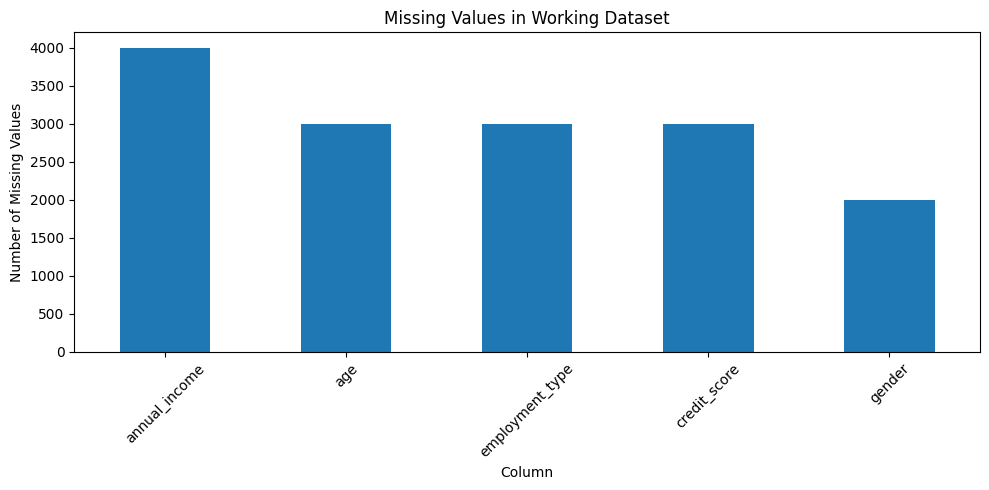

In [12]:
plt.figure(figsize=(10, 5))

missing_summary["Missing Count"].plot(
    kind="bar"
)

plt.title("Missing Values in Working Dataset")
plt.xlabel("Column")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Initial Missing Value Observation

The original dataset did not contain missing values, so I introduced controlled missing values into the working copy to satisfy the preprocessing requirements of the project.

The missing values are spread across both numerical and categorical variables. This gives me a practical way to compare different imputation methods later.

In [13]:
print("===== DATASET BASELINE =====")

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

print("\nDuplicate rows:", df.duplicated().sum())

print("\nTotal missing values:", df.isnull().sum().sum())

print("\nTarget distribution:")
print(df["default_flag"].value_counts())

print("\nTarget percentage:")
print(
    (df["default_flag"].value_counts(normalize=True) * 100)
    .round(2)
)

===== DATASET BASELINE =====
Rows: 100,000
Columns: 15

Duplicate rows: 0

Total missing values: 15000

Target distribution:
default_flag
0    58190
1    41810
Name: count, dtype: int64

Target percentage:
default_flag
0    58.19
1    41.81
Name: proportion, dtype: float64


In [14]:
# Convert join_date to datetime for inspection
df["join_date"] = pd.to_datetime(df["join_date"])

print("Earliest join date:", df["join_date"].min())
print("Latest join date:", df["join_date"].max())

print("\nNumber of unique joining dates:", df["join_date"].nunique())

Earliest join date: 2017-01-01 00:00:00
Latest join date: 2026-12-31 00:00:00

Number of unique joining dates: 3652


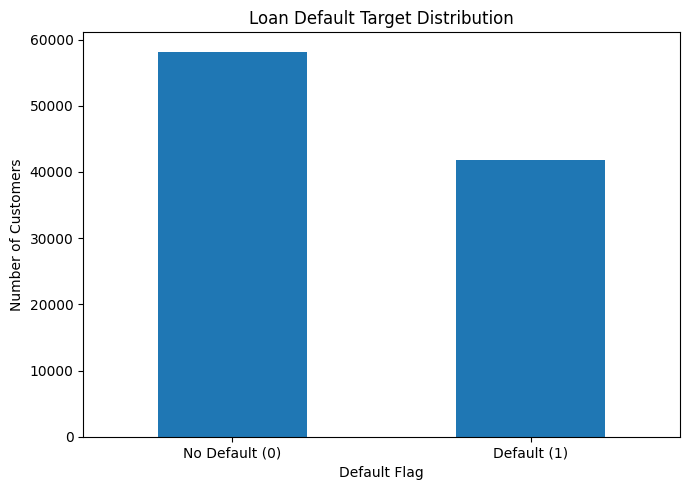

In [15]:
target_counts = df["default_flag"].value_counts().sort_index()

plt.figure(figsize=(7, 5))

target_counts.plot(kind="bar")

plt.title("Loan Default Target Distribution")
plt.xlabel("Default Flag")
plt.ylabel("Number of Customers")
plt.xticks([0, 1], ["No Default (0)", "Default (1)"], rotation=0)

plt.tight_layout()
plt.show()

### Target Observation

The target variable contains two classes, which confirms that this is a binary classification problem.

I am checking the distribution before preprocessing because a highly imbalanced target could affect a future Machine Learning model.

## 2. Loading Customer Metadata from JSON

The company also receives customer metadata in JSON format.

JSON is commonly used when information is exchanged between applications or APIs.

For this project, I will create a small sample customer metadata file and then read it into Python. I am keeping this source separate from the main CSV so that I can demonstrate how different data formats can be handled before combining information in a larger workflow.

In [16]:
# Sample customer metadata received in JSON format

customer_metadata = [
    {
        "customer_id": "CUST00001",
        "customer_segment": "Regular",
        "preferred_channel": "Mobile"
    },
    {
        "customer_id": "CUST00002",
        "customer_segment": "Premium",
        "preferred_channel": "Web"
    },
    {
        "customer_id": "CUST00003",
        "customer_segment": "Regular",
        "preferred_channel": "Mobile"
    },
    {
        "customer_id": "CUST00004",
        "customer_segment": "New",
        "preferred_channel": "Web"
    },
    {
        "customer_id": "CUST00005",
        "customer_segment": "Premium",
        "preferred_channel": "Mobile"
    }
]

json_file = "customer_metadata.json"

with open(json_file, "w") as file:
    json.dump(customer_metadata, file, indent=4)

print("JSON file created successfully.")

JSON file created successfully.


In [17]:
# Read the JSON file

with open(json_file, "r") as file:
    metadata_data = json.load(file)

print("JSON data loaded successfully.")
print(metadata_data)

JSON data loaded successfully.
[{'customer_id': 'CUST00001', 'customer_segment': 'Regular', 'preferred_channel': 'Mobile'}, {'customer_id': 'CUST00002', 'customer_segment': 'Premium', 'preferred_channel': 'Web'}, {'customer_id': 'CUST00003', 'customer_segment': 'Regular', 'preferred_channel': 'Mobile'}, {'customer_id': 'CUST00004', 'customer_segment': 'New', 'preferred_channel': 'Web'}, {'customer_id': 'CUST00005', 'customer_segment': 'Premium', 'preferred_channel': 'Mobile'}]


In [18]:
# Convert JSON records into a DataFrame

customer_metadata_df = pd.DataFrame(metadata_data)

print("Customer metadata:")
customer_metadata_df

Customer metadata:


,customer_id,customer_segment,preferred_channel
0,CUST00001,Regular,Mobile
1,CUST00002,Premium,Web
2,CUST00003,Regular,Mobile
3,CUST00004,New,Web
4,CUST00005,Premium,Mobile


### JSON Observation

The JSON data has been successfully converted into a Pandas DataFrame.

The important part here is that the source format does not need to be the same as the main dataset. Once the JSON records are loaded into a DataFrame, I can inspect and process them using familiar Pandas operations.

## 3. Loading Loan Repayment History from SQL

The company stores loan repayment information in a SQL database.

For this project I am using SQLite so that the database can be demonstrated directly inside the notebook without requiring a separate database server.

The repayment history contains the number of missed payments recorded for a customer. This information will become useful later when I perform binning and outlier treatment.

In [19]:
# Create a small SQLite database for repayment history

connection = sqlite3.connect("loan_repayment.db")

repayment_data = pd.DataFrame({
    "customer_id": [
        "CUST00001",
        "CUST00002",
        "CUST00003",
        "CUST00004",
        "CUST00005"
    ],
    "missed_payments": [0, 2, 1, 4, 0],
    "last_payment_status": [
        "On Time",
        "Late",
        "On Time",
        "Late",
        "On Time"
    ]
})

repayment_data.to_sql(
    "repayment_history",
    connection,
    if_exists="replace",
    index=False
)

print("SQLite database and repayment table created successfully.")

SQLite database and repayment table created successfully.


In [20]:
# Fetch repayment records using a SQL query

sql_query = """
SELECT
    customer_id,
    missed_payments,
    last_payment_status
FROM repayment_history
"""

repayment_history_df = pd.read_sql_query(
    sql_query,
    connection
)

print("Repayment history fetched successfully.")
repayment_history_df

Repayment history fetched successfully.


,customer_id,missed_payments,last_payment_status
0,CUST00001,0,On Time
1,CUST00002,2,Late
2,CUST00003,1,On Time
3,CUST00004,4,Late
4,CUST00005,0,On Time


In [21]:
# Close the database connection after completing the query

connection.close()

print("Database connection closed.")

Database connection closed.


### SQL Observation

The repayment records were successfully stored in SQLite and retrieved using a SQL query.

This is useful because real-world data projects often receive information from databases rather than only from CSV files.

The `missed_payments` variable is especially useful for this project because repayment history will later be used for numerical binning and outlier analysis.

## 4. Fetching External Economic Indicators from a Dummy API

The company may also use external economic information when assessing credit risk.

For example, changes in inflation or interest rates could provide additional context about the economic environment.

For this classroom project, I am simulating a small API response containing economic indicators. The purpose is to demonstrate how API-style JSON data can be received and converted into a DataFrame without introducing unnecessary external dependencies.

In [22]:
# Simulated response from an external economic indicator API

api_response = {
    "status": "success",
    "source": "Dummy Economic API",
    "data": [
        {
            "year": 2022,
            "inflation_rate": 6.7,
            "interest_rate": 5.4
        },
        {
            "year": 2023,
            "inflation_rate": 5.6,
            "interest_rate": 6.5
        },
        {
            "year": 2024,
            "inflation_rate": 4.8,
            "interest_rate": 6.5
        },
        {
            "year": 2025,
            "inflation_rate": 4.4,
            "interest_rate": 6.25
        },
        {
            "year": 2026,
            "inflation_rate": 4.1,
            "interest_rate": 6.0
        }
    ]
}

print("Dummy API response received successfully.")
print("API Status:", api_response["status"])

Dummy API response received successfully.
API Status: success


In [23]:
# Extract the actual records from the API response

economic_data = pd.DataFrame(
    api_response["data"]
)

economic_data

,year,inflation_rate,interest_rate
0,2022,6.7,5.40
1,2023,5.6,6.50
2,2024,4.8,6.50
3,2025,4.4,6.25
4,2026,4.1,6.00


### API Observation

The API-style response contains structured economic information that can be converted into a DataFrame.

For this project, I am treating this as an external supporting source rather than directly adding these values to every customer record.

The main purpose of this step is to demonstrate how an external API source can be received, inspected and prepared for further analysis.

## Data Acquisition Summary

At this stage, I have demonstrated four different data sources:

| Source | Format | Purpose |
|---|---|---|
| Main customer dataset | CSV | Customer credit risk information |
| Customer metadata | JSON | Additional customer information |
| Repayment history | SQL / SQLite | Missed payment information |
| Economic indicators | Dummy API | External economic context |

The main CSV dataset will remain the primary dataset for the rest of the project.

The other sources demonstrate how information from different formats can be loaded and inspected before being used in a larger data-processing workflow.

# PART C — DATA UNDERSTANDING & CLEANING

Before I start changing missing values or treating outliers, I first want to understand the current working dataset.

The `df` DataFrame is the copy that I will preprocess. The original `df_raw` dataset is still kept separately so that I can compare the results later if necessary.

I will start with the basic structure of the dataset using `info()`.

In [24]:
# Display the basic structure of the working dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 15 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   customer_id        100000 non-null  object        
 1   age                97000 non-null   float64       
 2   gender             98000 non-null   object        
 3   region             100000 non-null  object        
 4   education_level    100000 non-null  object        
 5   employment_type    97000 non-null   object        
 6   annual_income      96000 non-null   float64       
 7   loan_amount        100000 non-null  float64       
 8   loan_purpose       100000 non-null  object        
 9   credit_score       97000 non-null   float64       
 10  repayment_history  100000 non-null  int64         
 11  transaction_count  100000 non-null  int64         
 12  spending_ratio     100000 non-null  float64       
 13  join_date          100000 non-null  datetime6

### Dataset Structure Observation

The dataset contains 100,000 customer records and 15 columns.

I can see a mixture of numerical and categorical variables. The `join_date` column has already been converted to a datetime format, while the categorical columns are stored as object values.

The missing-value counts also confirm that the working dataset contains missing values in the columns selected earlier for the preprocessing exercises.

## Descriptive Statistics

Next, I want to look at the numerical variables in more detail.

The `describe()` function gives me useful statistics such as the mean, standard deviation, minimum, maximum and quartiles.

This is especially useful for this project because some of the financial variables were deliberately generated with skewed distributions and outliers.

In [25]:
# Summary statistics for numerical columns

df.describe()

,age,annual_income,loan_amount,credit_score,repayment_history,transaction_count,spending_ratio,join_date,default_flag
count,97000.000000,9.600000e+04,1.000000e+05,97000.000000,100000.000000,100000.000000,100000.000000,100000,100000.000000
mean,41.981948,8.191485e+05,1.699062e+06,684.849631,1.216490,110.433730,41.558386,2021-12-22 02:01:19.200000,0.418100
min,21.000000,1.200000e+05,2.000000e+04,385.380000,0.000000,4.000000,5.000000,2017-01-01 00:00:00,0.000000
25%,34.000000,4.181656e+05,5.512960e+05,640.210000,0.000000,73.000000,27.300000,2019-06-25 00:00:00,0.000000
50%,41.000000,6.514537e+05,1.164468e+06,684.890000,1.000000,103.000000,40.310000,2021-12-20 00:00:00,0.000000
75%,49.000000,1.018473e+06,2.191520e+06,730.030000,2.000000,139.000000,54.570000,2024-06-18 00:00:00,1.000000
max,70.000000,2.349906e+07,3.314082e+07,850.000000,8.000000,500.000000,112.210000,2026-12-31 00:00:00,1.000000
std,10.283906,6.460293e+05,1.815648e+06,66.199913,1.105746,51.062757,18.736815,NaN,0.493249


### Descriptive Statistics Observation

The summary statistics give me an initial idea of the range and spread of the numerical variables.

The financial variables have noticeably larger ranges than variables such as age or repayment history. I can also see that annual income and loan amount have relatively high maximum values compared with their typical values.

This suggests that I should investigate these variables more carefully during the outlier-handling stage rather than automatically removing extreme observations.

## Checking Categorical Variables

I also want to understand the categories present in the main categorical columns.

This helps me identify whether there are unexpected values or categories that may need attention before encoding.

In [26]:
# Check the categories in the main categorical variables

categorical_columns = [
    "gender",
    "region",
    "education_level",
    "employment_type",
    "loan_purpose"
]

for column in categorical_columns:
    print(f"\n===== {column.upper()} =====")
    print(df[column].value_counts(dropna=False))


===== GENDER =====
gender
Male      49792
Female    46275
NaN        2000
Other      1933
Name: count, dtype: int64

===== REGION =====
region
West     29018
South    26871
North    23998
East     20113
Name: count, dtype: int64

===== EDUCATION_LEVEL =====
education_level
Graduate         47923
Secondary        27173
Post-Graduate    16871
Primary           8033
Name: count, dtype: int64

===== EMPLOYMENT_TYPE =====
employment_type
Salaried         60028
Self-Employed    29191
Unemployed        7781
NaN               3000
Name: count, dtype: int64

===== LOAN_PURPOSE =====
loan_purpose
Car          25172
Home         25049
Business     19903
Other        14992
Education    14884
Name: count, dtype: int64


### Categorical Variable Observation

The categorical columns contain the expected categories from the dataset design.

There are also missing values in `gender` and `employment_type`, which I will handle using categorical imputation rather than dropping those customer records.

## Data Quality Report

Before starting the cleaning process, I want one table that gives me a quick overview of the quality of each column.

I will check:

- Data type
- Missing values
- Missing percentage
- Number of unique values
- Duplicate values
- Minimum and maximum values for numerical columns

This gives me a baseline that I can compare against after cleaning.

In [27]:
# Create a simple data quality report

quality_report = pd.DataFrame({
    "Data Type": df.dtypes.astype(str),
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().mean() * 100).round(2),
    "Unique Values": df.nunique(dropna=False)
})

quality_report["Duplicate Values"] = (
    df.apply(lambda column: column.duplicated().sum())
)

quality_report

,Data Type,Missing Count,Missing Percentage,Unique Values,Duplicate Values
customer_id,object,0,0.0,100000,0
age,float64,3000,3.0,51,99949
gender,object,2000,2.0,4,99996
region,object,0,0.0,4,99996
education_level,object,0,0.0,4,99996
employment_type,object,3000,3.0,4,99996
annual_income,float64,4000,4.0,95514,4486
loan_amount,float64,0,0.0,99787,213
loan_purpose,object,0,0.0,5,99995
credit_score,float64,3000,3.0,27143,72857


### Data Quality Observation

The report gives me a column-by-column view of the current dataset.

The main issues at this stage are the intentionally introduced missing values. I do not want to remove the rows immediately because that would unnecessarily reduce the size of the dataset.

Instead, I will compare several missing-value techniques and then select appropriate methods for the final working dataset.

## Pandas Profiling Data Quality Report

The manual quality report above gives me a compact overview of the dataset.

To complement it, I will also generate a profiling report containing a broader automated summary of the dataset.

This report is being generated from the working dataset before the final preprocessing stages so that I can inspect the original data-quality issues.

In [28]:
# Generate an automated Pandas profiling report

try:
    from ydata_profiling import ProfileReport

    profile = ProfileReport(
        df,
        title="Customer Credit Risk Dataset — Data Quality Report",
        minimal=True
    )

    profile.to_file(
        "customer_credit_risk_data_quality_report.html"
    )

    print(
        "Pandas profiling report created successfully."
    )
    print(
        "File: customer_credit_risk_data_quality_report.html"
    )

except ImportError:
    print(
        "ydata-profiling is not installed."
    )
    print(
        "Install it with: pip install ydata-profiling"
    )

c:\Users\Dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\Dell\AppData\Local\Temp\ipykernel_15884\2252621933.py:4: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport
Export report to file: 100%|██████████| 1/1 [00:00<00:00, 13.93it/s]

Pandas profiling report created successfully.
File: customer_credit_risk_data_quality_report.html


## Missing Value Handling — Mean Imputation

Mean imputation replaces a missing numerical value with the average of the available values.

I will demonstrate this using `age`.

Mean imputation is simple, but it can be influenced by extreme values, so I want to compare it with other methods.

In [29]:
# Create a copy for the mean-imputation demonstration

df_mean = df.copy()

age_mean = df_mean["age"].mean()

df_mean["age"] = df_mean["age"].fillna(age_mean)

print("Mean age used for imputation:", round(age_mean, 2))
print("Remaining missing age values:", df_mean["age"].isnull().sum())

Mean age used for imputation: 41.98
Remaining missing age values: 0


### Mean Imputation Observation

Mean imputation successfully removes the missing values from `age`.

However, the mean can be affected by unusually high or low observations. For variables with strong skew or outliers, the median may be a safer choice.

## Median Imputation

Median imputation replaces missing values with the middle value of the available observations.

I will compare this approach with mean imputation because median values are generally less affected by extreme observations.

In [30]:
# Median imputation for age

df_median = df.copy()

age_median = df_median["age"].median()

df_median["age"] = df_median["age"].fillna(age_median)

print("Median age used for imputation:", age_median)
print("Remaining missing age values:", df_median["age"].isnull().sum())

Median age used for imputation: 41.0
Remaining missing age values: 0


### Median Imputation Observation

The median also removes all missing values from `age`.

For this project, median imputation is a useful option because it is simple to understand and is less sensitive to extreme observations than the mean.

## SimpleImputer for Numerical Data

Instead of manually calculating the mean or median, scikit-learn provides `SimpleImputer`.

This makes the process easier to reuse when several columns need the same treatment.

In [31]:
# Use SimpleImputer with the median strategy

df_simple_num = df.copy()

numeric_imputer = SimpleImputer(strategy="median")

df_simple_num[["age", "annual_income", "credit_score"]] = (
    numeric_imputer.fit_transform(
        df_simple_num[["age", "annual_income", "credit_score"]]
    )
)

print("Missing values after numerical SimpleImputer:")
print(
    df_simple_num[
        ["age", "annual_income", "credit_score"]
    ].isnull().sum()
)

Missing values after numerical SimpleImputer:
age              0
annual_income    0
credit_score     0
dtype: int64


### SimpleImputer Observation

The median strategy has filled the missing numerical values across the selected columns.

Using `SimpleImputer` is more practical than manually filling every column because the same approach can be applied consistently to multiple variables.

## SimpleImputer for Categorical Data

Categorical variables cannot be filled using numerical averages.

For `gender` and `employment_type`, I will use the most frequent category.

This means that missing values are replaced with the category that appears most often in the available data.

In [32]:
# Use the most frequent category for categorical missing values

df_simple_cat = df.copy()

categorical_imputer = SimpleImputer(
    strategy="most_frequent"
)

df_simple_cat[["gender", "employment_type"]] = (
    categorical_imputer.fit_transform(
        df_simple_cat[["gender", "employment_type"]]
    )
)

print("Missing values after categorical imputation:")
print(
    df_simple_cat[
        ["gender", "employment_type"]
    ].isnull().sum()
)

Missing values after categorical imputation:
gender             0
employment_type    0
dtype: int64


### Categorical Imputation Observation

The most frequent strategy is suitable here because `gender` and `employment_type` are categorical variables.

It also keeps the original categories rather than creating artificial numerical values.

## Missing Indicator and Random Sample Imputation

Sometimes I may want to preserve information about whether a value was originally missing.

A missing indicator creates a new binary column:

- `1` → the original value was missing
- `0` → the original value was available

For `annual_income`, I will also demonstrate random sample imputation, where missing values are replaced using randomly selected values from the existing non-missing observations.

In [33]:
# Work on a separate copy for this demonstration

df_random = df.copy()

# Create an indicator before filling the missing values
df_random["annual_income_missing"] = (
    df_random["annual_income"].isnull().astype(int)
)

# Collect the available income values
available_income = (
    df_random["annual_income"]
    .dropna()
    .to_numpy()
)

# Find where income is missing
missing_income_mask = df_random["annual_income"].isnull()

# Make the result reproducible
rng = np.random.default_rng(42)

# Randomly sample existing income values
sampled_income = rng.choice(
    available_income,
    size=missing_income_mask.sum(),
    replace=True
)

# Fill the missing values
df_random.loc[
    missing_income_mask,
    "annual_income"
] = sampled_income

print(
    "Original missing income values:",
    missing_income_mask.sum()
)

print(
    "Remaining missing income values:",
    df_random["annual_income"].isnull().sum()
)

print(
    "Missing indicator values:"
)

print(
    df_random["annual_income_missing"].value_counts()
)

Original missing income values: 4000
Remaining missing income values: 0
Missing indicator values:
annual_income_missing
0    96000
1     4000
Name: count, dtype: int64


### Random Sample Imputation Observation

Random sample imputation keeps the replacement values within the existing income distribution instead of replacing every missing value with exactly the same number.

The additional missing indicator is useful because the original missingness information is not completely lost.

## KNN Imputation

KNN Imputation estimates a missing value by looking at similar observations.

For this demonstration, I will use the numerical financial variables:

- `annual_income`
- `loan_amount`
- `credit_score`

I am using a separate copy so that this experiment does not change the main working dataset.

In [34]:
# KNN imputation demonstration

df_knn = df.copy()

knn_columns = [
    "annual_income",
    "loan_amount",
    "credit_score"
]

# Use a reproducible sample for this demonstration.
# The final dataset will use the simpler imputation strategy.
knn_demo = df_knn[knn_columns].sample(
    n=min(5000, len(df_knn)),
    random_state=42
).copy()

knn_imputer = KNNImputer(
    n_neighbors=5
)

knn_demo[knn_columns] = knn_imputer.fit_transform(
    knn_demo[knn_columns]
)

print("KNN imputation demonstration completed.")
print("Rows used for demonstration:", len(knn_demo))

print("\nMissing values after KNN imputation:")
print(
    knn_demo[knn_columns].isnull().sum()
)

knn_demo.head()

KNN imputation demonstration completed.
Rows used for demonstration: 5000

Missing values after KNN imputation:
annual_income    0
loan_amount      0
credit_score     0
dtype: int64


,annual_income,loan_amount,credit_score
75721,863485.41,145718.12,614.35
80184,1574798.88,6832815.91,525.38
19864,271578.05,898262.25,757.92
76699,143007.92,121673.02,755.99
92991,866278.42,3397499.91,693.27


### KNN Imputation Observation

KNN imputation successfully fills the missing numerical values by using information from similar records.

It is more data-driven than simply replacing every missing value with the mean or median. However, it is also more computationally expensive and can be affected by differences in feature scales.

For the final dataset, I will choose a method based on simplicity, consistency and the purpose of the project rather than automatically choosing the most complicated method.

### KNN Imputation Observation

KNN imputation successfully fills the missing numerical values by using information from similar records.

It is more data-driven than simply replacing every missing value with the mean or median. However, it is also more computationally expensive and can be affected by differences in feature scales.

For the final dataset, I will choose a method based on simplicity, consistency and the purpose of the project rather than automatically choosing the most complicated method.

In [35]:
# Iterative imputation demonstration

df_iterative = df.copy()

iterative_columns = [
    "age",
    "annual_income",
    "loan_amount",
    "credit_score",
    "repayment_history",
    "transaction_count",
    "spending_ratio"
]

iterative_imputer = IterativeImputer(
    random_state=42,
    max_iter=10
)

df_iterative[iterative_columns] = (
    iterative_imputer.fit_transform(
        df_iterative[iterative_columns]
    )
)

print("Missing values after Iterative Imputation:")

print(
    df_iterative[
        iterative_columns
    ].isnull().sum()
)

Missing values after Iterative Imputation:
age                  0
annual_income        0
loan_amount          0
credit_score         0
repayment_history    0
transaction_count    0
spending_ratio       0
dtype: int64


### Iterative Imputation Observation

Iterative imputation uses relationships between several numerical variables when estimating missing values.

It can therefore be more flexible than simple mean or median imputation. However, it is also more complex, so I would not automatically use it for every column just because it is available.

## Complete Case Analysis

Another way to handle missing data is to remove rows containing missing values.

This is known as Complete Case Analysis.

I will demonstrate it on a copy of the dataset rather than applying it to the final working dataset because I do not want to unnecessarily lose customer records.

In [36]:
# Complete Case Analysis demonstration

df_complete_case = df.dropna()

print("Original rows:", len(df))
print("Rows after Complete Case Analysis:", len(df_complete_case))
print(
    "Rows removed:",
    len(df) - len(df_complete_case)
)

Original rows: 100000
Rows after Complete Case Analysis: 85890
Rows removed: 14110


### Complete Case Observation

Complete Case Analysis removes every row containing at least one missing value.

Although this is simple, it reduces the amount of available data. Since this project starts with 100,000 customer records, I would prefer imputation for the final dataset rather than discarding customers unnecessarily.

## Comparing Missing Value Strategies

I have now demonstrated several approaches to missing-value handling.

The methods have different advantages, so I would not use one technique blindly across every column.

I will summarise the approaches before deciding what to use for the final working dataset.

In [37]:
# Compare the main missing-value approaches

comparison = pd.DataFrame({
    "Method": [
        "Mean Imputation",
        "Median Imputation",
        "SimpleImputer - Numerical",
        "Most Frequent",
        "Random Sample + Indicator",
        "KNN Imputation",
        "Iterative Imputation",
        "Complete Case Analysis"
    ],
    "Main Use": [
        "Numerical data",
        "Numerical data with possible outliers",
        "Multiple numerical columns",
        "Categorical data",
        "Skewed numerical data",
        "Numerical data using similar records",
        "Numerical data using relationships",
        "Rows with missing values"
    ],
    "Main Advantage": [
        "Very simple",
        "Less affected by extreme values",
        "Easy to reuse",
        "Simple categorical treatment",
        "Preserves distribution and missingness information",
        "Uses similar observations",
        "Uses relationships between variables",
        "Very easy to apply"
    ],
    "Main Limitation": [
        "Affected by outliers",
        "Can reduce variation",
        "Still a simple strategy",
        "May favour the majority category",
        "Adds an extra column",
        "More computationally expensive",
        "More complex",
        "Can remove many observations"
    ]
})

comparison

,Method,Main Use,Main Advantage,Main Limitation
0,Mean Imputation,Numerical data,Very simple,Affected by outliers
1,Median Imputation,Numerical data with possible outliers,Less affected by extreme values,Can reduce variation
2,SimpleImputer - Numerical,Multiple numerical columns,Easy to reuse,Still a simple strategy
3,Most Frequent,Categorical data,Simple categorical treatment,May favour the majority category
4,Random Sample + Indicator,Skewed numerical data,Preserves distribution and missingness informa...,Adds an extra column
5,KNN Imputation,Numerical data using similar records,Uses similar observations,More computationally expensive
6,Iterative Imputation,Numerical data using relationships,Uses relationships between variables,More complex
7,Complete Case Analysis,Rows with missing values,Very easy to apply,Can remove many observations


### Missing Value Strategy Decision

After comparing the methods, I will use simple and explainable methods for the final cleaned dataset.

For the final working dataset:

- Numerical variables will use median imputation where appropriate.
- Categorical variables will use the most frequent category.
- The missing indicator and random sample approach has been demonstrated separately.
- KNN and Iterative Imputation have also been demonstrated separately.
- Complete Case Analysis will not be used for the final dataset because it would unnecessarily remove customer records.

The more advanced approaches are useful demonstrations, but the final method should remain practical and easy to explain.

In [38]:
# Final missing-value treatment

# Numerical columns
final_numeric_columns = [
    "age",
    "annual_income",
    "credit_score"
]

final_numeric_imputer = SimpleImputer(
    strategy="median"
)

df[final_numeric_columns] = (
    final_numeric_imputer.fit_transform(
        df[final_numeric_columns]
    )
)

# Categorical columns
final_categorical_columns = [
    "gender",
    "employment_type"
]

final_categorical_imputer = SimpleImputer(
    strategy="most_frequent"
)

df[final_categorical_columns] = (
    final_categorical_imputer.fit_transform(
        df[final_categorical_columns]
    )
)

print("Final missing-value treatment completed.")

Final missing-value treatment completed.


In [39]:
# Check the dataset after missing-value treatment

final_missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (
        df.isnull().mean() * 100
    ).round(2)
})

final_missing[
    final_missing["Missing Count"] > 0
]

,Missing Count,Missing Percentage


### Final Missing Value Check

The missing-value treatment has been completed and the working dataset no longer contains missing values in the columns that were intentionally affected.

I have kept the original `df_raw` dataset unchanged and only modified the working copy `df`.

This gives me a clean starting point for the next stage, where I will investigate numerical outliers.

# PART D — OUTLIER HANDLING

After dealing with the missing values, the next issue I want to investigate is outliers.

Outliers are not automatically bad data. In a credit-risk dataset, an unusually high income or loan amount could represent a genuine customer rather than an error.

For that reason, I will first identify extreme observations using several methods and compare the results before deciding how to treat them.

The main variables I will investigate are `annual_income`, `loan_amount`, and `credit_score`.

In [40]:
# Keep a copy of the cleaned dataset before outlier treatment.
# This will help me make a before/after comparison later.

df_before_outliers = df.copy()

outlier_columns = [
    "annual_income",
    "loan_amount",
    "credit_score"
]

print("Columns selected for outlier analysis:")
print(outlier_columns)

Columns selected for outlier analysis:
['annual_income', 'loan_amount', 'credit_score']


### Outlier Analysis Setup

I am focusing on `annual_income`, `loan_amount`, and `credit_score` because these are the variables where extreme values could have the greatest effect on later preprocessing.

I have also saved a copy of the dataset before treatment so that I can compare the original and treated distributions.

### Outlier Analysis Setup

I am focusing on `annual_income`, `loan_amount`, and `credit_score` because these are the variables where extreme values could have the greatest effect on later preprocessing.

I have also saved a copy of the dataset before treatment so that I can compare the original and treated distributions.

In [41]:
# Detect potential outliers using the Z-score method

zscore_results = []

for column in outlier_columns:
    scores = zscore(df[column])
    outlier_mask = np.abs(scores) > 3

    zscore_results.append({
        "Column": column,
        "Outliers": int(outlier_mask.sum()),
        "Percentage": round(outlier_mask.mean() * 100, 2)
    })

zscore_report = pd.DataFrame(zscore_results)

zscore_report

,Column,Outliers,Percentage
0,annual_income,1641,1.64
1,loan_amount,1943,1.94
2,credit_score,141,0.14


### Z-Score Observation

The Z-score method identifies a number of unusually distant observations in the selected numerical variables.

However, I do not want to treat these observations as errors automatically. Since `annual_income` and `loan_amount` are naturally skewed, I will use IQR and percentile methods as additional checks.

## 2. IQR Method

The Interquartile Range (IQR) method identifies observations outside the range:

- Lower bound = Q1 − 1.5 × IQR
- Upper bound = Q3 + 1.5 × IQR

I prefer to compare this method with Z-score because the IQR is less affected by extreme values.

In [42]:
# Detect potential outliers using the IQR method

iqr_results = []

for column in outlier_columns:
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_mask = (
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    )

    iqr_results.append({
        "Column": column,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outliers": int(outlier_mask.sum()),
        "Percentage": round(outlier_mask.mean() * 100, 2)
    })

iqr_report = pd.DataFrame(iqr_results)

iqr_report

,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outliers,Percentage
0,annual_income,426452.9050,9.968757e+05,5.704228e+05,-4.291813e+05,1.852510e+06,5600,5.60
1,loan_amount,551296.0175,2.191520e+06,1.640224e+06,-1.909040e+06,4.651856e+06,5953,5.95
2,credit_score,641.8875,7.285300e+02,8.664250e+01,5.119238e+02,8.584937e+02,451,0.45


### IQR Observation

The IQR method gives a different view of the extreme observations.

This is useful for my dataset because income and loan amount are not perfectly symmetrical variables. The IQR method does not depend as heavily on the mean and standard deviation, so it gives me another reasonable way to identify unusual values.

## 3. Percentile Method

The percentile method identifies observations outside selected lower and upper percentiles.

For this project, I will use the 1st and 99th percentiles as the boundaries.

This approach is useful when I want to limit the influence of the most extreme observations while retaining the majority of the dataset.

In [43]:
# Detect potential outliers using the 1st and 99th percentiles

percentile_results = []

for column in outlier_columns:
    lower_percentile = df[column].quantile(0.01)
    upper_percentile = df[column].quantile(0.99)

    outlier_mask = (
        (df[column] < lower_percentile) |
        (df[column] > upper_percentile)
    )

    percentile_results.append({
        "Column": column,
        "1st Percentile": lower_percentile,
        "99th Percentile": upper_percentile,
        "Outliers": int(outlier_mask.sum()),
        "Percentage": round(outlier_mask.mean() * 100, 2)
    })

percentile_report = pd.DataFrame(percentile_results)

percentile_report

,Column,1st Percentile,99th Percentile,Outliers,Percentage
0,annual_income,145285.5519,3.144855e+06,2000,2.0
1,loan_amount,59762.6740,8.975177e+06,2000,2.0
2,credit_score,530.5599,8.378200e+02,1999,2.0


### Percentile Observation

The percentile method gives me a fixed proportion of the data at each end of the distribution.

This is particularly useful when the goal is to reduce the influence of extreme values rather than completely remove the observations.

## Comparing the Outlier Detection Methods

I have now used three different approaches to identify extreme observations.

Instead of relying on a single method, I will compare their results before deciding how to treat the data.

In [44]:
# Combine the number of outliers detected by each method

outlier_comparison = pd.DataFrame({
    "Column": outlier_columns,
    "Z-Score": zscore_report["Outliers"].values,
    "IQR": iqr_report["Outliers"].values,
    "Percentile": percentile_report["Outliers"].values
})

outlier_comparison

,Column,Z-Score,IQR,Percentile
0,annual_income,1641,5600,2000
1,loan_amount,1943,5953,2000
2,credit_score,141,451,1999


### Outlier Method Comparison

The three methods do not identify exactly the same observations.

That is expected because they use different definitions of an outlier. Z-score focuses on distance from the mean, IQR focuses on the middle 50% of the data, and the percentile method fixes the proportion of observations considered extreme.

For this dataset, I will use winsorization for the final treatment because I want to reduce the influence of extreme observations without deleting customer records.

## Visualising Outliers Before Treatment

Numbers are useful, but a boxplot makes the extreme observations much easier to see.

I will create boxplots for the three selected numerical variables before applying any treatment.

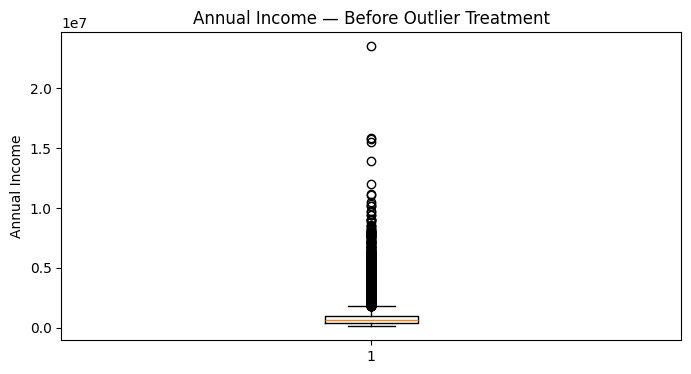

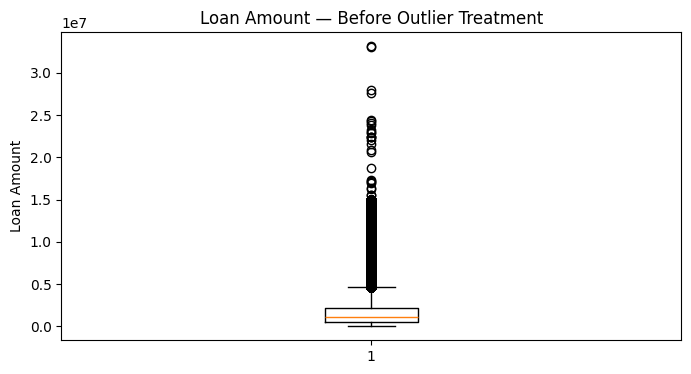

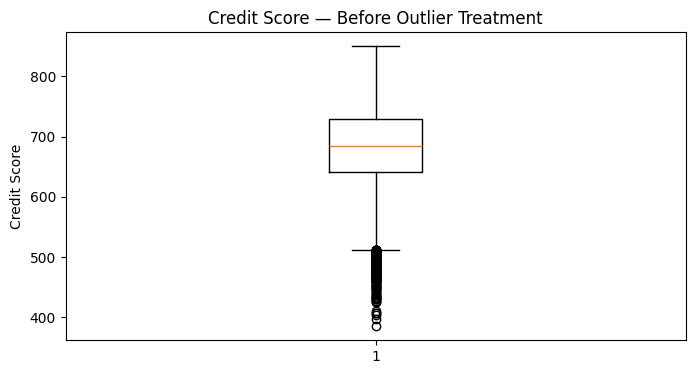

In [45]:
# Boxplots before outlier treatment

for column in outlier_columns:
    plt.figure(figsize=(8, 4))

    plt.boxplot(df[column])

    plt.title(f"{column.replace('_', ' ').title()} — Before Outlier Treatment")
    plt.ylabel(column.replace("_", " ").title())

    plt.show()

### Before-Treatment Observation

The boxplots make the extreme observations more visible than the numerical tables alone.

The financial variables show noticeable extreme values, which supports the decision to investigate them before using scaling and transformation methods later in the project.

## 4. Winsorization

After comparing the detection methods, I will use winsorization to treat the extreme values.

Winsorization limits very high and very low observations to selected percentile boundaries.

For this dataset, I will use the 1st and 99th percentiles. This allows me to keep all customer records while reducing the influence of extreme financial values.

I am choosing this approach instead of deleting rows because an unusually high income or loan amount could still represent a genuine customer.

In [46]:
# Apply winsorization to the selected numerical variables

df_winsorized = df.copy()

for column in outlier_columns:
    df_winsorized[column] = np.asarray(
        winsorize(
            df_winsorized[column],
            limits=[0.01, 0.01]
        )
    )

print("Winsorization completed.")

Winsorization completed.


## Before and After Winsorization

I will now compare the minimum and maximum values before and after winsorization.

This gives me a simple way to confirm that the extreme values have been capped without reducing the number of rows.

In [47]:
# Compare the range before and after winsorization

winsorization_comparison = pd.DataFrame({
    "Column": outlier_columns,
    "Before Min": [
        df_before_outliers[column].min()
        for column in outlier_columns
    ],
    "After Min": [
        df_winsorized[column].min()
        for column in outlier_columns
    ],
    "Before Max": [
        df_before_outliers[column].max()
        for column in outlier_columns
    ],
    "After Max": [
        df_winsorized[column].max()
        for column in outlier_columns
    ]
})

winsorization_comparison

,Column,Before Min,After Min,Before Max,After Max
0,annual_income,120000.00,145285.76,23499060.76,3144844.11
1,loan_amount,20000.00,59763.32,33140821.61,8975163.69
2,credit_score,385.38,530.56,850.00,837.82


In [48]:
# Count how many observations were changed by winsorization

changed_values = []

for column in outlier_columns:
    changed = (
        df_before_outliers[column] != df_winsorized[column]
    ).sum()

    changed_values.append({
        "Column": column,
        "Values Changed": int(changed),
        "Percentage Changed": round(
            changed / len(df_winsorized) * 100,
            2
        )
    })

changed_values_report = pd.DataFrame(changed_values)

changed_values_report

,Column,Values Changed,Percentage Changed
0,annual_income,2000,2.0
1,loan_amount,2000,2.0
2,credit_score,1999,2.0


### Winsorization Observation

Winsorization changed only the observations at the extreme ends of the selected distributions.

Importantly, no customer records were deleted. The dataset therefore keeps its original number of rows while reducing the effect of unusually large or small numerical values.

## Updating the Working Dataset

The outlier analysis is now complete.

I will use the winsorized version as my working dataset for the next stages of feature engineering, encoding and scaling.

In [49]:
# Use the winsorized dataset for the remaining preprocessing steps

df = df_winsorized.copy()

print("Working dataset updated.")
print("Shape:", df.shape)

Working dataset updated.
Shape: (100000, 15)


## Visualising the Data After Winsorization

I will repeat the boxplots after treatment so that I can visually compare the distributions with the earlier plots.

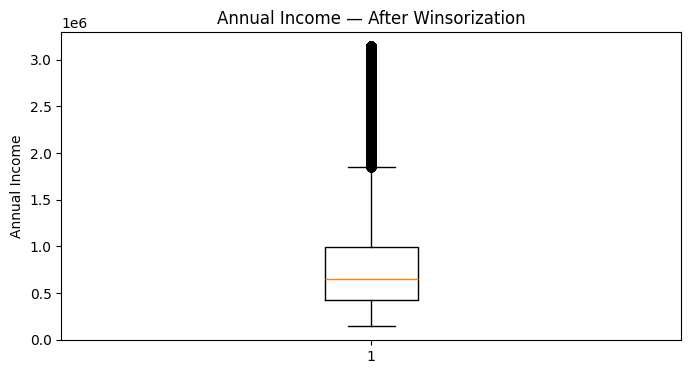

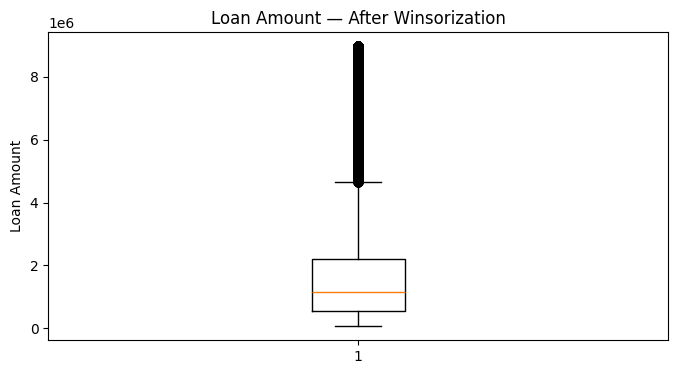

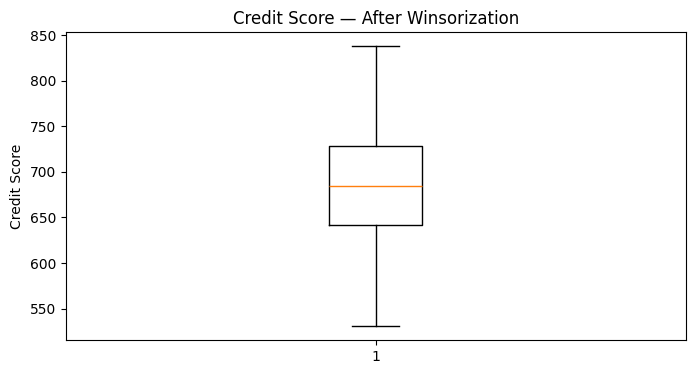

In [50]:
# Boxplots after outlier treatment

for column in outlier_columns:
    plt.figure(figsize=(8, 4))

    plt.boxplot(df[column])

    plt.title(f"{column.replace('_', ' ').title()} — After Winsorization")
    plt.ylabel(column.replace("_", " ").title())

    plt.show()

### After-Treatment Observation

After winsorization, the most extreme values have been capped.

The important point is that I have reduced the influence of extreme observations without removing customer records. This gives me a cleaner numerical dataset to use during the later scaling and transformation stages.

## Final Outlier Treatment Check

Before moving on, I want to make sure that the outlier treatment did not accidentally change the size of the dataset or introduce missing values.

In [51]:
# Final checks after outlier treatment

print("Dataset shape:", df.shape)
print("Total missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

print("\nNumerical summary after winsorization:")
df[outlier_columns].describe().T

Dataset shape: (100000, 15)
Total missing values: 0
Duplicate rows: 0

Numerical summary after winsorization:


,count,mean,std,min,25%,50%,75%,max
annual_income,100000.0,8.007250e+05,5.532844e+05,145285.76,426452.9050,651453.725,9.968757e+05,3144844.11
loan_amount,100000.0,1.669450e+06,1.642668e+06,59763.32,551296.0175,1164467.540,2.191520e+06,8975163.69
credit_score,100000.0,6.849789e+02,6.436440e+01,530.56,641.8875,684.890,7.285300e+02,837.82


### Part D Conclusion

The outlier-handling stage is now complete.

I compared Z-score, IQR and percentile methods before selecting winsorization for the final treatment.

I chose winsorization because it reduces the influence of extreme values while keeping the customer records in the dataset.

The cleaned dataset is now ready for the feature-engineering stage.

# PART E — FEATURE ENGINEERING

Now that the missing values and extreme numerical values have been handled, I can start preparing the variables for machine learning.

The dataset contains different types of variables, including numerical, categorical and date variables. These variables cannot all be handled in the same way.

I will therefore create useful date features, encode categorical variables, and convert selected numerical variables into meaningful groups where appropriate.

## 1. Identifying Variable Types

Before transforming anything, I want to separate the variables according to their data type.

This makes it easier to decide which preprocessing technique is appropriate for each column.

In [52]:
# Separate the main variables by their role and type

numerical_features = [
    "age",
    "annual_income",
    "loan_amount",
    "credit_score",
    "repayment_history",
    "transaction_count",
    "spending_ratio"
]

categorical_features = [
    "gender",
    "region",
    "education_level",
    "employment_type",
    "loan_purpose"
]

date_features = [
    "join_date"
]

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

print("\nDate features:")
print(date_features)

Numerical features:
['age', 'annual_income', 'loan_amount', 'credit_score', 'repayment_history', 'transaction_count', 'spending_ratio']

Categorical features:
['gender', 'region', 'education_level', 'employment_type', 'loan_purpose']

Date features:
['join_date']


### Variable Type Observation

The dataset contains a mixture of numerical, categorical and date variables.

For example, `annual_income` and `credit_score` contain numerical information, while `gender` and `region` are categorical. The `join_date` column is different again because useful information can be extracted from the date itself.

Because of these differences, I will use different feature-engineering techniques for each group.

## 2. Date Feature Engineering

The original `join_date` contains more information than just the complete date.

For example, the year can tell us when the customer joined the bank, while the month and weekday can be used as separate numerical features.

I will extract these components and keep the original date available for reference.

In [53]:
# Extract useful information from the customer join date

df["join_year"] = df["join_date"].dt.year
df["join_month"] = df["join_date"].dt.month
df["join_day"] = df["join_date"].dt.day
df["join_weekday"] = df["join_date"].dt.dayofweek

print("Date features created successfully.")

df[
    [
        "join_date",
        "join_year",
        "join_month",
        "join_day",
        "join_weekday"
    ]
].head()

Date features created successfully.


,join_date,join_year,join_month,join_day,join_weekday
0,2018-07-30,2018,7,30,0
1,2025-06-04,2025,6,4,2
2,2018-12-25,2018,12,25,1
3,2017-06-02,2017,6,2,4
4,2022-02-21,2022,2,21,0


### Date Feature Observation

The date has now been broken into four separate features.

This gives the future model access to individual parts of the date instead of treating the entire date as one value. The weekday is represented numerically so that it can be processed as a numerical feature later.

## 3. Ordinal Encoding — Education Level

`education_level` is different from a normal categorical variable because the categories have a natural order.

I will therefore use ordinal encoding rather than assigning the values randomly.

In [54]:
# Ordinal encoding for education level

education_order = [
    "Primary",
    "Secondary",
    "Graduate",
    "Post-Graduate"
]

education_encoder = OrdinalEncoder(
    categories=[education_order]
)

df["education_level_encoded"] = education_encoder.fit_transform(
    df[["education_level"]]
).ravel()

df[
    [
        "education_level",
        "education_level_encoded"
    ]
].drop_duplicates().sort_values(
    "education_level_encoded"
)

,education_level,education_level_encoded
13,Primary,0.0
0,Secondary,1.0
3,Graduate,2.0
2,Post-Graduate,3.0


### Ordinal Encoding Observation

Ordinal encoding works well here because education levels have a meaningful progression.

The encoded values preserve the relationship between the categories: Primary comes before Secondary, which comes before Graduate and Post-Graduate.

## 4. Label Encoding — Gender

`gender` is a categorical variable without a natural numerical order.

For the purpose of this project, I will demonstrate label encoding so that each category is represented by an integer.

In [55]:
# Label encoding for gender

gender_encoder = LabelEncoder()

df["gender_encoded"] = gender_encoder.fit_transform(
    df["gender"]
)

gender_mapping = pd.DataFrame({
    "Original Category": gender_encoder.classes_,
    "Encoded Value": range(len(gender_encoder.classes_))
})

gender_mapping

,Original Category,Encoded Value
0,Female,0
1,Male,1
2,Other,2


### Label Encoding Observation

Label encoding has converted the gender categories into integer values.

Unlike education, these numbers do not represent a ranking. They are simply labels assigned to the categories, which is why I will not interpret a higher encoded value as meaning "more" or "less" gender.

## 5. One-Hot Encoding — Region

`region` is a nominal categorical variable, so there is no meaningful order between North, South, East and West.

One-hot encoding is suitable because it creates separate binary columns without suggesting an artificial ranking.

In [56]:
# One-hot encode region

region_encoder = OneHotEncoder(
    sparse_output=False,
    handle_unknown="ignore"
)

region_encoded = region_encoder.fit_transform(
    df[["region"]]
)

region_encoded_df = pd.DataFrame(
    region_encoded,
    columns=region_encoder.get_feature_names_out(["region"]),
    index=df.index
)

df = pd.concat(
    [df, region_encoded_df],
    axis=1
)

df[
    [
        "region",
        *region_encoder.get_feature_names_out(["region"])
    ]
].head()

,region,region_East,region_North,region_South,region_West
0,West,0.0,0.0,0.0,1.0
1,East,1.0,0.0,0.0,0.0
2,North,0.0,1.0,0.0,0.0
3,West,0.0,0.0,0.0,1.0
4,North,0.0,1.0,0.0,0.0


### Region Encoding Observation

One-hot encoding has converted the four region categories into separate binary features.

This avoids giving the regions an artificial numerical order.

## 6. One-Hot Encoding — Loan Purpose

I will apply the same idea to `loan_purpose`.

There is no natural ranking between purposes such as Home, Car, Education and Business, so one-hot encoding is appropriate.

In [57]:
# One-hot encode loan purpose

loan_purpose_encoder = OneHotEncoder(
    sparse_output=False,
    handle_unknown="ignore"
)

loan_purpose_encoded = loan_purpose_encoder.fit_transform(
    df[["loan_purpose"]]
)

loan_purpose_encoded_df = pd.DataFrame(
    loan_purpose_encoded,
    columns=loan_purpose_encoder.get_feature_names_out(
        ["loan_purpose"]
    ),
    index=df.index
)

df = pd.concat(
    [df, loan_purpose_encoded_df],
    axis=1
)

df[
    [
        "loan_purpose",
        *loan_purpose_encoder.get_feature_names_out(
            ["loan_purpose"]
        )
    ]
].head()

,loan_purpose,loan_purpose_Business,loan_purpose_Car,loan_purpose_Education,loan_purpose_Home,loan_purpose_Other
0,Business,1.0,0.0,0.0,0.0,0.0
1,Home,0.0,0.0,0.0,1.0,0.0
2,Car,0.0,1.0,0.0,0.0,0.0
3,Home,0.0,0.0,0.0,1.0,0.0
4,Home,0.0,0.0,0.0,1.0,0.0


### Loan Purpose Observation

The loan purpose has now been converted into separate binary features.

At this stage I am keeping the original categorical columns as well because I am demonstrating the preprocessing techniques. The final ML-ready dataset will later contain only the features needed for modelling.

## 7. Binning Repayment History

`repayment_history` represents the number of missed payments during the previous 12 months.

Instead of only looking at the exact number, I can also group customers into broader repayment-risk categories.

I will use equal-width binning for this demonstration.

In [58]:
# Equal-width binning for repayment history

repayment_bins = KBinsDiscretizer(
    n_bins=4,
    encode="ordinal",
    strategy="uniform",
    subsample=None
)

df["repayment_history_bin"] = repayment_bins.fit_transform(
    df[["repayment_history"]]
).ravel()

df[
    [
        "repayment_history",
        "repayment_history_bin"
    ]
].head(10)

,repayment_history,repayment_history_bin
0,2,1.0
1,1,0.0
2,0,0.0
3,2,1.0
4,2,1.0
5,3,1.0
6,2,1.0
7,1,0.0
8,3,1.0
9,2,1.0


### Repayment History Observation

The exact number of missed payments has been supplemented with a binned version.

This can be useful when a model benefits from broader risk groups rather than relying only on the exact numerical value.

## 8. Equal-Width Binning — Annual Income

Annual income has a wide range and is right-skewed.

I will divide the income range into equal-width groups to demonstrate discretization.

In [59]:
# Equal-width income groups

income_uniform_bins = KBinsDiscretizer(
    n_bins=5,
    encode="ordinal",
    strategy="uniform",
    subsample=None
)

df["income_uniform_bin"] = income_uniform_bins.fit_transform(
    df[["annual_income"]]
).ravel()

df[
    [
        "annual_income",
        "income_uniform_bin"
    ]
].head(10)

,annual_income,income_uniform_bin
0,655313.00,0.0
1,609720.06,0.0
2,244292.60,0.0
3,419056.12,0.0
4,465101.82,0.0
5,406025.18,0.0
6,851811.00,1.0
7,439465.16,0.0
8,970497.29,1.0
9,644340.14,0.0


### Equal-Width Binning Observation

Equal-width binning divides the complete income range into equally sized intervals.

Because income is skewed, some intervals may contain considerably more customers than others. I will compare this with quantile binning next.

## 9. Quantile Binning — Annual Income

Quantile binning takes a different approach.

Instead of making the intervals equal in numerical width, it attempts to place a similar number of observations into each group.

This is useful for comparing the effect of a different discretization strategy on a skewed variable such as income.

In [60]:
# Quantile-based income groups

income_quantile_bins = KBinsDiscretizer(
    n_bins=5,
    encode="ordinal",
    strategy="quantile",
    subsample=None
)

df["income_quantile_bin"] = income_quantile_bins.fit_transform(
    df[["annual_income"]]
).ravel()

df[
    [
        "annual_income",
        "income_quantile_bin"
    ]
].head(10)

,annual_income,income_quantile_bin
0,655313.00,2.0
1,609720.06,2.0
2,244292.60,0.0
3,419056.12,1.0
4,465101.82,1.0
5,406025.18,1.0
6,851811.00,3.0
7,439465.16,1.0
8,970497.29,3.0
9,644340.14,2.0


In [61]:
# Compare how many customers fall into each type of income bin

income_bin_comparison = pd.DataFrame({
    "Equal Width": df["income_uniform_bin"].value_counts().sort_index(),
    "Quantile": df["income_quantile_bin"].value_counts().sort_index()
})

income_bin_comparison

,Equal Width,Quantile
0.0,59845,20000
1.0,26998,20000
2.0,8316,20000
3.0,2803,20000
4.0,2038,20000


### Income Binning Observation

The two methods divide the income data differently.

Equal-width binning is based on the numerical range, while quantile binning is based on the distribution of observations. Since income is skewed, quantile binning can provide more balanced groups.

## 10. K-Means Binning — Transaction Count

Transaction count is another numerical variable with a wide range.

For this demonstration, I will use K-Means based discretization to group customers according to similar transaction-count values.

This is different from equal-width and quantile binning because the groups are created from the structure of the data itself.

In [62]:
# K-Means based binning for transaction count

transaction_kmeans_bins = KBinsDiscretizer(
    n_bins=4,
    encode="ordinal",
    strategy="kmeans",
    subsample=None,
    random_state=42
)

df["transaction_kmeans_bin"] = (
    transaction_kmeans_bins.fit_transform(
        df[["transaction_count"]]
    ).ravel()
)

df[
    [
        "transaction_count",
        "transaction_kmeans_bin"
    ]
].head(10)

,transaction_count,transaction_kmeans_bin
0,160,2.0
1,145,2.0
2,119,1.0
3,100,1.0
4,168,2.0
5,122,1.0
6,181,2.0
7,101,1.0
8,154,2.0
9,53,0.0


### K-Means Binning Observation

K-Means binning has grouped transaction counts according to clusters in the numerical distribution.

This gives me another way of representing transaction activity besides keeping the raw transaction count.

## 11. Binarization — Credit Score

The project requires a binary feature based on whether the customer's credit score is greater than 700.

I will use `Binarizer` for this rather than manually creating the condition.

In [63]:
# Binarize credit score using the required threshold

credit_binarizer = Binarizer(
    threshold=700
)

df["credit_score_above_700"] = credit_binarizer.fit_transform(
    df[["credit_score"]]
).ravel()

df[
    [
        "credit_score",
        "credit_score_above_700"
    ]
].head(10)

,credit_score,credit_score_above_700
0,769.05,1.0
1,665.15,0.0
2,623.72,0.0
3,626.12,0.0
4,702.31,1.0
5,722.35,1.0
6,837.82,1.0
7,614.86,0.0
8,703.89,1.0
9,723.11,1.0


### Credit Score Binarization Observation

The new feature indicates whether a customer's credit score is above 700.

A value of `1` means the score is above the threshold, while `0` means it is 700 or below.

This gives a simple binary representation that can be useful alongside the original credit score.

## Feature Engineering Check

Before moving on to feature scaling, I want to check that the new features have been created correctly and that the working dataset still has the expected number of customer records.

In [64]:
# Check the dataset after feature engineering

new_features = [
    "join_year",
    "join_month",
    "join_day",
    "join_weekday",
    "education_level_encoded",
    "gender_encoded",
    "repayment_history_bin",
    "income_uniform_bin",
    "income_quantile_bin",
    "transaction_kmeans_bin",
    "credit_score_above_700"
]

print("Dataset shape:", df.shape)

print("\nNew feature columns:")
print(new_features)

print("\nMissing values in new features:")
print(df[new_features].isnull().sum())

print("\nData types of new features:")
print(df[new_features].dtypes)

Dataset shape: (100000, 35)

New feature columns:
['join_year', 'join_month', 'join_day', 'join_weekday', 'education_level_encoded', 'gender_encoded', 'repayment_history_bin', 'income_uniform_bin', 'income_quantile_bin', 'transaction_kmeans_bin', 'credit_score_above_700']

Missing values in new features:
join_year                  0
join_month                 0
join_day                   0
join_weekday               0
education_level_encoded    0
gender_encoded             0
repayment_history_bin      0
income_uniform_bin         0
income_quantile_bin        0
transaction_kmeans_bin     0
credit_score_above_700     0
dtype: int64

Data types of new features:
join_year                    int32
join_month                   int32
join_day                     int32
join_weekday                 int32
education_level_encoded    float64
gender_encoded               int64
repayment_history_bin      float64
income_uniform_bin         float64
income_quantile_bin        float64
transaction_kmeans

### Part E Progress Check

The main feature-engineering requirements have now been demonstrated.

I have extracted information from the join date, encoded the categorical variables, created binned numerical features, applied K-Means binning to transaction count, and created the required binary credit-score feature.

The dataset still contains the original customer records, so I can now move on to feature scaling.

# PART F — FEATURE SCALING

The next step is feature scaling.

The numerical variables in this dataset have very different ranges. For example, age is measured in years, while annual income and loan amount are measured in rupees.

If these variables are used together in algorithms that are sensitive to scale, the larger numerical values could have a disproportionate influence.

I will therefore compare several scaling techniques and then decide which approach makes the most sense for the final preprocessing workflow.

## 1. Selecting Numerical Features

Before applying any scaler, I need to decide which columns should actually be scaled.

I will use numerical predictor variables and deliberately leave `default_flag` out because it is the target variable, not an input feature.

I will also exclude `customer_id` because it is an identifier rather than a meaningful numerical feature.

In [65]:
# Select numerical predictor columns for the scaling demonstrations.
# The target and customer identifier should not be scaled.

scaling_features = [
    column
    for column in df.select_dtypes(include=np.number).columns
    if column != "default_flag"
    and column != "customer_id"
]

print("Numerical features selected for scaling:")
print(scaling_features)

print("\nNumber of features:", len(scaling_features))

Numerical features selected for scaling:
['age', 'annual_income', 'loan_amount', 'credit_score', 'repayment_history', 'transaction_count', 'spending_ratio', 'join_year', 'join_month', 'join_day', 'join_weekday', 'education_level_encoded', 'gender_encoded', 'region_East', 'region_North', 'region_South', 'region_West', 'loan_purpose_Business', 'loan_purpose_Car', 'loan_purpose_Education', 'loan_purpose_Home', 'loan_purpose_Other', 'repayment_history_bin', 'income_uniform_bin', 'income_quantile_bin', 'transaction_kmeans_bin', 'credit_score_above_700']

Number of features: 27


### Scaling Feature Selection Observation

I have deliberately excluded `default_flag` because it is the target variable.

I have also excluded `customer_id` because the identifier does not represent a meaningful customer characteristic.

This keeps the scaling process focused on actual numerical predictors.

## 2. Comparing the Original Numerical Ranges

Before scaling the variables, I want to see how different their ranges are.

This will help me understand why scaling may be useful for the later Machine Learning workflow.

In [66]:
# Compare the original ranges of the numerical predictors

scaling_range = df[scaling_features].agg(
    ["min", "max"]
).T

scaling_range["Range"] = (
    scaling_range["max"] -
    scaling_range["min"]
)

scaling_range.sort_values(
    "Range",
    ascending=False
)

,min,max,Range
loan_amount,59763.32,8975163.69,8915400.37
annual_income,145285.76,3144844.11,2999558.35
transaction_count,4.00,500.00,496.00
credit_score,530.56,837.82,307.26
spending_ratio,5.00,112.21,107.21
age,21.00,70.00,49.00
join_day,1.00,31.00,30.00
join_month,1.00,12.00,11.00
join_year,2017.00,2026.00,9.00
repayment_history,0.00,8.00,8.00


### Original Range Observation

The numerical variables are clearly measured on very different scales.

For example, income and loan amount have much larger numerical values than age or transaction count. This is one of the main reasons I need to investigate feature scaling before preparing the final ML-ready dataset.

## 3. Standardization — StandardScaler

Standardization transforms a numerical variable so that it is centred around a mean of approximately 0 with a standard deviation of approximately 1.

I will demonstrate this using the main financial variables `annual_income` and `loan_amount`, as required by the project.

In [67]:
# Standardize annual income and loan amount

standard_scaler = StandardScaler()

standardized_data = standard_scaler.fit_transform(
    df[["annual_income", "loan_amount"]]
)

standardized_df = pd.DataFrame(
    standardized_data,
    columns=[
        "annual_income_standardized",
        "loan_amount_standardized"
    ],
    index=df.index
)

standardized_df.head()

,annual_income_standardized,loan_amount_standardized
0,-0.262817,0.089930
1,-0.345222,-0.555307
2,-1.005695,-0.564705
3,-0.689828,-0.258555
4,-0.606605,0.372770


In [68]:
# Check the mean and standard deviation after standardization

standardized_summary = standardized_df.agg(
    ["mean", "std"]
).T

standardized_summary

,mean,std
annual_income_standardized,-4.916956e-17,1.000005
loan_amount_standardized,-1.939782e-17,1.000005


### Standardization Observation

After standardization, the two financial variables are placed on a comparable scale.

The mean is close to zero and the standard deviation is close to one. This makes StandardScaler a useful option when I want to preserve the overall distribution while putting variables onto a common scale.

## 4. Min-Max Scaling

Min-Max scaling transforms values into a fixed range, normally between 0 and 1.

This can be useful when I want all variables to have a common bounded range.

In [69]:
# Apply Min-Max scaling to all selected numerical predictors

minmax_scaler = MinMaxScaler()

minmax_data = minmax_scaler.fit_transform(
    df[scaling_features]
)

minmax_df = pd.DataFrame(
    minmax_data,
    columns=[
        f"{column}_minmax"
        for column in scaling_features
    ],
    index=df.index
)

minmax_df.head()

,age_minmax,annual_income_minmax,loan_amount_minmax,credit_score_minmax,repayment_history_minmax,transaction_count_minmax,spending_ratio_minmax,join_year_minmax,join_month_minmax,join_day_minmax,...,loan_purpose_Business_minmax,loan_purpose_Car_minmax,loan_purpose_Education_minmax,loan_purpose_Home_minmax,loan_purpose_Other_minmax,repayment_history_bin_minmax,income_uniform_bin_minmax,income_quantile_bin_minmax,transaction_kmeans_bin_minmax,credit_score_above_700_minmax
0,0.265306,0.170034,0.197121,0.776183,0.250,0.314516,0.207910,0.111111,0.545455,0.966667,...,1.0,0.0,0.0,0.0,0.0,0.333333,0.0,0.50,0.666667,1.0
1,0.142857,0.154834,0.078236,0.438033,0.125,0.284274,0.084787,0.888889,0.454545,0.100000,...,0.0,0.0,0.0,1.0,0.0,0.000000,0.0,0.50,0.666667,0.0
2,0.591837,0.033007,0.076505,0.303196,0.000,0.231855,0.407331,0.111111,1.000000,0.800000,...,0.0,1.0,0.0,0.0,0.0,0.000000,0.0,0.00,0.333333,0.0
3,0.632653,0.091270,0.132913,0.311007,0.250,0.193548,0.378230,0.000000,0.454545,0.033333,...,0.0,0.0,0.0,1.0,0.0,0.333333,0.0,0.25,0.333333,0.0
4,0.285714,0.106621,0.249234,0.558973,0.250,0.330645,0.342226,0.555556,0.090909,0.666667,...,0.0,0.0,0.0,1.0,0.0,0.333333,0.0,0.25,0.666667,1.0


In [70]:
# Check the minimum and maximum after Min-Max scaling

minmax_summary = pd.DataFrame({
    "Minimum": minmax_df.min(),
    "Maximum": minmax_df.max()
})

minmax_summary

,Minimum,Maximum
age_minmax,0.0,1.0
annual_income_minmax,0.0,1.0
loan_amount_minmax,0.0,1.0
credit_score_minmax,0.0,1.0
repayment_history_minmax,0.0,1.0
transaction_count_minmax,0.0,1.0
spending_ratio_minmax,0.0,1.0
join_year_minmax,0.0,1.0
join_month_minmax,0.0,1.0
join_day_minmax,0.0,1.0


### Min-Max Observation

Min-Max scaling has placed the numerical variables into a common range between 0 and 1.

This is easy to interpret and can be useful when a model works better with bounded numerical inputs.

## 4A. Normalization

Normalization is different from feature-wise scaling because it works across each individual observation.

For this demonstration, I will use `Normalizer` to scale each customer's numerical feature vector to unit length.

I am keeping this as a demonstration rather than automatically using it in the final pipeline because normalization changes the relationship between values within each row.

In [71]:
# Import Normalizer for the normalization demonstration

from sklearn.preprocessing import Normalizer

normalizer = Normalizer()

normalized_data = normalizer.fit_transform(
    df[scaling_features]
)

normalized_df = pd.DataFrame(
    normalized_data,
    columns=[
        f"{column}_normalized"
        for column in scaling_features
    ],
    index=df.index
)

normalized_df.head()

,age_normalized,annual_income_normalized,loan_amount_normalized,credit_score_normalized,repayment_history_normalized,transaction_count_normalized,spending_ratio_normalized,join_year_normalized,join_month_normalized,join_day_normalized,...,loan_purpose_Business_normalized,loan_purpose_Car_normalized,loan_purpose_Education_normalized,loan_purpose_Home_normalized,loan_purpose_Other_normalized,repayment_history_bin_normalized,income_uniform_bin_normalized,income_quantile_bin_normalized,transaction_kmeans_bin_normalized,credit_score_above_700_normalized
0,0.000018,0.339237,0.940700,0.000398,1.035344e-06,0.000083,0.000014,0.001045,3.623704e-06,0.000016,...,5.176720e-07,0.000000,0.0,0.000000e+00,0.0,5.176720e-07,0.0,1.035344e-06,1.035344e-06,5.176720e-07
1,0.000029,0.627139,0.778904,0.000684,1.028569e-06,0.000149,0.000014,0.002083,6.171413e-06,0.000004,...,0.000000e+00,0.000000,0.0,1.028569e-06,0.0,0.000000e+00,0.0,2.057138e-06,2.057138e-06,0.000000e+00
2,0.000064,0.312785,0.949820,0.000799,0.000000e+00,0.000152,0.000062,0.002584,1.536444e-05,0.000032,...,0.000000e+00,0.000001,0.0,0.000000e+00,0.0,0.000000e+00,0.0,0.000000e+00,1.280370e-06,0.000000e+00
3,0.000040,0.319067,0.947731,0.000477,1.522787e-06,0.000076,0.000035,0.001536,4.568360e-06,0.000002,...,0.000000e+00,0.000000,0.0,7.613933e-07,0.0,7.613933e-07,0.0,7.613933e-07,7.613933e-07,0.000000e+00
4,0.000015,0.199726,0.979851,0.000302,8.588466e-07,0.000072,0.000018,0.000868,8.588466e-07,0.000009,...,0.000000e+00,0.000000,0.0,4.294233e-07,0.0,4.294233e-07,0.0,4.294233e-07,8.588466e-07,4.294233e-07


In [72]:
# Check the length of each normalized row

row_lengths = np.sqrt(
    (normalized_df ** 2).sum(axis=1)
)

print(
    "First five normalized row lengths:"
)

print(row_lengths.head())

First five normalized row lengths:
0    1.0
1    1.0
2    1.0
3    1.0
4    1.0
dtype: float64


### Normalization Observation

Normalization has scaled each customer's numerical feature vector so that its overall length is approximately 1.

This is different from Min-Max scaling, which scales each feature independently.

For this project, I am demonstrating normalization because it is part of the required scaling topics, but I will not automatically choose it for the final pipeline without considering whether it suits the intended Machine Learning algorithm.

## 5. MaxAbs Scaling

MaxAbs scaling divides each feature by its largest absolute value.

It is useful when I want to scale numerical features while keeping the sign of the original values.

In [73]:
# Apply MaxAbs scaling to the numerical predictors

maxabs_scaler = MaxAbsScaler()

maxabs_data = maxabs_scaler.fit_transform(
    df[scaling_features]
)

maxabs_df = pd.DataFrame(
    maxabs_data,
    columns=[
        f"{column}_maxabs"
        for column in scaling_features
    ],
    index=df.index
)

maxabs_df.head()

,age_maxabs,annual_income_maxabs,loan_amount_maxabs,credit_score_maxabs,repayment_history_maxabs,transaction_count_maxabs,spending_ratio_maxabs,join_year_maxabs,join_month_maxabs,join_day_maxabs,...,loan_purpose_Business_maxabs,loan_purpose_Car_maxabs,loan_purpose_Education_maxabs,loan_purpose_Home_maxabs,loan_purpose_Other_maxabs,repayment_history_bin_maxabs,income_uniform_bin_maxabs,income_quantile_bin_maxabs,transaction_kmeans_bin_maxabs,credit_score_above_700_maxabs
0,0.485714,0.208377,0.202467,0.917918,0.250,0.320,0.243205,0.996051,0.583333,0.967742,...,1.0,0.0,0.0,0.0,0.0,0.333333,0.0,0.50,0.666667,1.0
1,0.400000,0.193879,0.084374,0.793906,0.125,0.290,0.125568,0.999506,0.500000,0.129032,...,0.0,0.0,0.0,1.0,0.0,0.000000,0.0,0.50,0.666667,0.0
2,0.714286,0.077680,0.082654,0.744456,0.000,0.238,0.433740,0.996051,1.000000,0.806452,...,0.0,1.0,0.0,0.0,0.0,0.000000,0.0,0.00,0.333333,0.0
3,0.742857,0.133252,0.138686,0.747320,0.250,0.200,0.405935,0.995558,0.500000,0.064516,...,0.0,0.0,0.0,1.0,0.0,0.333333,0.0,0.25,0.333333,0.0
4,0.500000,0.147893,0.254233,0.838259,0.250,0.336,0.371536,0.998026,0.166667,0.677419,...,0.0,0.0,0.0,1.0,0.0,0.333333,0.0,0.25,0.666667,1.0


In [74]:
# Check the maximum absolute value after MaxAbs scaling

maxabs_summary = maxabs_df.abs().max().to_frame(
    name="Maximum Absolute Value"
)

maxabs_summary

,Maximum Absolute Value
age_maxabs,1.0
annual_income_maxabs,1.0
loan_amount_maxabs,1.0
credit_score_maxabs,1.0
repayment_history_maxabs,1.0
transaction_count_maxabs,1.0
spending_ratio_maxabs,1.0
join_year_maxabs,1.0
join_month_maxabs,1.0
join_day_maxabs,1.0


### MaxAbs Observation

MaxAbs scaling brings the largest absolute value of each feature to approximately 1.

For this dataset, most of the numerical variables are positive, so the practical difference from Min-Max scaling is easier to see as a change in scale rather than a major change in interpretation.

## 6. Robust Scaling

Robust Scaling uses the median and interquartile range instead of the mean and standard deviation.

This makes it less sensitive to extreme observations.

Even though I have already treated the main outliers, I want to demonstrate RobustScaler because it is one of the required techniques and is useful when numerical variables may still contain unusual values.

In [75]:
# Apply Robust Scaling

robust_scaler = RobustScaler()

robust_data = robust_scaler.fit_transform(
    df[scaling_features]
)

robust_df = pd.DataFrame(
    robust_data,
    columns=[
        f"{column}_robust"
        for column in scaling_features
    ],
    index=df.index
)

robust_df.head()

,age_robust,annual_income_robust,loan_amount_robust,credit_score_robust,repayment_history_robust,transaction_count_robust,spending_ratio_robust,join_year_robust,join_month_robust,join_day_robust,...,loan_purpose_Business_robust,loan_purpose_Car_robust,loan_purpose_Education_robust,loan_purpose_Home_robust,loan_purpose_Other_robust,repayment_history_bin_robust,income_uniform_bin_robust,income_quantile_bin_robust,transaction_kmeans_bin_robust,credit_score_above_700_robust
0,-0.466667,0.006766,0.397938,0.971348,0.5,0.863636,-0.477448,-0.6,0.000000,0.933333,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.5,1.0
1,-0.866667,-0.073163,-0.248257,-0.227833,0.0,0.636364,-0.961496,0.8,-0.166667,-0.800000,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.5,0.0
2,0.600000,-0.713788,-0.257669,-0.706005,-0.5,0.242424,0.306564,-0.6,0.833333,0.600000,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,-1.0,0.0,0.0
3,0.733333,-0.407413,0.048935,-0.678305,0.5,-0.045455,0.192153,-0.8,-0.166667,-0.933333,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,-0.5,0.0,0.0
4,-0.400000,-0.326691,0.681198,0.201056,0.5,0.984848,0.050605,0.2,-0.833333,0.333333,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,-0.5,0.5,1.0


In [76]:
# Inspect the median and spread after Robust Scaling

robust_summary = robust_df.agg(
    ["median", "min", "max"]
).T

robust_summary

,median,min,max
age_robust,0.000000e+00,-1.333333,1.933333
annual_income_robust,0.000000e+00,-0.887356,4.371127
loan_amount_robust,-7.097543e-17,-0.673508,4.761969
credit_score_robust,0.000000e+00,-1.781227,1.765069
repayment_history_robust,0.000000e+00,-0.500000,3.500000
transaction_count_robust,0.000000e+00,-1.500000,6.015152
spending_ratio_robust,0.000000e+00,-1.294829,2.636597
join_year_robust,0.000000e+00,-0.800000,1.000000
join_month_robust,0.000000e+00,-1.000000,0.833333
join_day_robust,0.000000e+00,-1.000000,1.000000


### Robust Scaling Observation

RobustScaler uses the median and interquartile range, so it is less affected by extreme observations than StandardScaler.

This makes it a useful alternative for financial variables where unusually large values can occur.

## 7. Comparing the Scaling Methods

The four scaling methods solve a similar problem, but they do it in different ways.

I will summarise their main characteristics before deciding what to use in the final preprocessing workflow.

In [77]:
# Summary of the scaling techniques demonstrated

scaling_comparison = pd.DataFrame({
    "Method": [
        "StandardScaler",
        "MinMaxScaler",
        "MaxAbsScaler",
        "RobustScaler"
    ],
    "Main Idea": [
        "Mean = 0 and standard deviation = 1",
        "Values scaled to a fixed range",
        "Scale using maximum absolute value",
        "Use median and IQR"
    ],
    "Useful When": [
        "Features have different scales",
        "A bounded range is useful",
        "Sign and relative magnitude should be preserved",
        "Data may contain extreme values"
    ]
})

scaling_comparison

,Method,Main Idea,Useful When
0,StandardScaler,Mean = 0 and standard deviation = 1,Features have different scales
1,MinMaxScaler,Values scaled to a fixed range,A bounded range is useful
2,MaxAbsScaler,Scale using maximum absolute value,Sign and relative magnitude should be preserved
3,RobustScaler,Use median and IQR,Data may contain extreme values


### Scaling Decision

There is no single scaling method that is automatically best for every dataset.

For the final preprocessing workflow, I will use StandardScaler for the main numerical features because it provides a familiar and interpretable standardised scale.

RobustScaler is also a useful alternative for financial variables because it is less sensitive to extreme observations.

Min-Max and MaxAbs scaling have been demonstrated separately to satisfy the project requirements and to understand how their results differ.

## Visual Comparison of Scaling

I will compare the distribution of annual income before and after StandardScaler.

The goal is not to change the underlying information, but to show how the numerical scale changes.

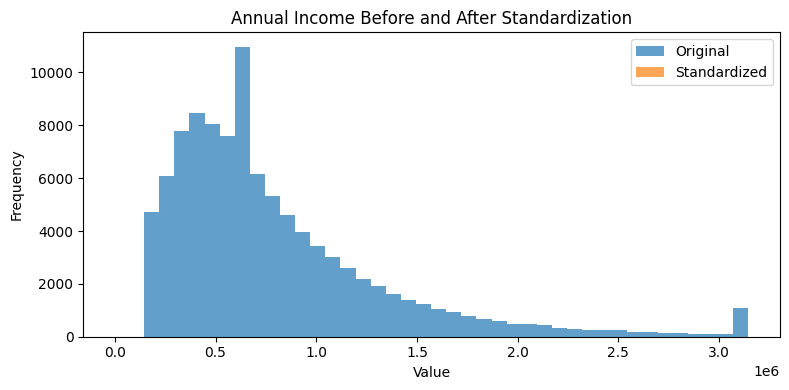

In [78]:
# Compare annual income before and after standardization

plt.figure(figsize=(8, 4))

plt.hist(
    df["annual_income"],
    bins=40,
    alpha=0.7,
    label="Original"
)

plt.hist(
    standardized_df["annual_income_standardized"],
    bins=40,
    alpha=0.7,
    label="Standardized"
)

plt.title("Annual Income Before and After Standardization")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()
plt.show()

### Scaling Visual Observation

The distribution has not been fundamentally changed by standardization. Instead, the numerical scale has been shifted and rescaled.

This is the main purpose of feature scaling: variables measured in very different units can be brought onto a more comparable scale.

## Feature Scaling Check

Before moving to transformations and feature construction, I want to confirm that the scaling demonstrations produced numerical values without changing the number of customer records in the working dataset.

In [79]:
# Final Part F checks

print("Original working dataset shape:", df.shape)

print("\nStandardized data shape:", standardized_df.shape)
print("Min-Max data shape:", minmax_df.shape)
print("MaxAbs data shape:", maxabs_df.shape)
print("Robust data shape:", robust_df.shape)

print("\nMissing values in the original working dataset:")
print(df[scaling_features].isnull().sum().sum())

print("\nTarget column remains unchanged:")
print(df["default_flag"].value_counts().sort_index())

Original working dataset shape: (100000, 35)

Standardized data shape: (100000, 2)
Min-Max data shape: (100000, 27)
MaxAbs data shape: (100000, 27)
Robust data shape: (100000, 27)

Missing values in the original working dataset:
0

Target column remains unchanged:
default_flag
0    58190
1    41810
Name: count, dtype: int64


### Part F Conclusion

The required scaling methods have now been demonstrated.

StandardScaler, MinMaxScaler, MaxAbsScaler and RobustScaler all place numerical variables onto different but more comparable scales.

For the final ML-ready workflow, I will make the scaling choice based on the type of numerical variable and keep the target variable separate from all preprocessing transformations.

# PART G — FEATURE CONSTRUCTION & TRANSFORMATION

The dataset is now cleaned, the main outliers have been treated, categorical variables have been encoded for demonstration, and several scaling methods have been compared.

The next step is to investigate whether mathematical transformations can make some numerical variables easier for a Machine Learning model to work with.

I will first check the skewness of the numerical variables. Based on that result, I will demonstrate log, reciprocal and square-root transformations using `FunctionTransformer`, followed by Box-Cox and Yeo-Johnson transformations using `PowerTransformer`.

I will then construct a few additional features that could be useful for understanding customer credit risk.

In [80]:
# Check the current working dataset before starting Part G

print("Current dataset shape:", df.shape)

print("\nMissing values:", df.isnull().sum().sum())

print("Duplicate rows:", df.duplicated().sum())

print("\nNumerical columns:")
print(numerical_features)

Current dataset shape: (100000, 35)

Missing values: 0
Duplicate rows: 0

Numerical columns:
['age', 'annual_income', 'loan_amount', 'credit_score', 'repayment_history', 'transaction_count', 'spending_ratio']


### Part G Starting Check

The working dataset is ready for the transformation stage.

There are no remaining missing values in the cleaned working data, so I can focus on the shape and distribution of the numerical variables before deciding which transformations are appropriate.

## 1. Checking Numerical Skewness

Before applying a mathematical transformation, I want to check how strongly each numerical variable is skewed.

A positive skew means that the distribution has a longer tail towards larger values. This is particularly relevant for financial variables such as income and loan amount.

I will use the skewness values as a guide rather than automatically transforming every column.

In [81]:
# Calculate skewness for the main numerical features

skewness_report = pd.DataFrame({
    "Feature": numerical_features,
    "Skewness": [
        df[column].skew()
        for column in numerical_features
    ]
})

skewness_report["Absolute Skewness"] = (
    skewness_report["Skewness"].abs()
)

skewness_report.sort_values(
    "Absolute Skewness",
    ascending=False
)

,Feature,Skewness,Absolute Skewness
2,loan_amount,2.044852,2.044852
1,annual_income,1.820766,1.820766
5,transaction_count,0.951297,0.951297
4,repayment_history,0.908808,0.908808
0,age,0.386703,0.386703
6,spending_ratio,0.319098,0.319098
3,credit_score,-0.010384,0.010384


### Skewness Observation

The skewness results show that the numerical variables do not all have the same distribution.

The financial variables, especially `annual_income` and `loan_amount`, are more strongly right-skewed than variables such as age or transaction count.

Because of this, transformations are worth investigating for the financial variables rather than applying them to every numerical column automatically.

## 2. FunctionTransformer — Log Transformation

The log transformation can reduce positive skewness by compressing larger values more strongly than smaller values.

I will demonstrate it on `spending_ratio`. The values in this dataset are positive, so a logarithmic transformation is mathematically appropriate.

I will use `log1p`, which is a safe version of the log transformation when zero values could occur.

In [82]:
# Log transformation using FunctionTransformer

log_transformer = FunctionTransformer(
    np.log1p,
    validate=False
)

spending_log = log_transformer.transform(
    df[["spending_ratio"]]
)

# Convert the transformed result into a 1D NumPy array
df["spending_ratio_log"] = (
    spending_log
    .to_numpy()
    .ravel()
)

df[
    [
        "spending_ratio",
        "spending_ratio_log"
    ]
].head()

,spending_ratio,spending_ratio_log
0,27.29,3.342508
1,14.09,2.714032
2,48.67,3.905401
3,45.55,3.840527
4,41.69,3.753965


In [83]:
# Compare skewness before and after the log transformation

log_skewness = pd.DataFrame({
    "Version": [
        "Original",
        "Log Transformed"
    ],
    "Skewness": [
        df["spending_ratio"].skew(),
        df["spending_ratio_log"].skew()
    ]
})

log_skewness

,Version,Skewness
0,Original,0.319098
1,Log Transformed,-0.908632


### Log Transformation Observation

The log transformation compresses larger spending-ratio values.

I am keeping both versions for demonstration purposes. The transformed feature can be useful when the original variable has a long right tail, while the original feature is still useful for comparison and interpretation.

## 3. FunctionTransformer — Reciprocal Transformation

A reciprocal transformation replaces a value with its inverse.

This transformation can strongly reduce the influence of larger numerical values, but it should only be used when the values are non-zero.

The current `spending_ratio` values are positive, so I can safely demonstrate the transformation.

In [84]:
# Reciprocal transformation using FunctionTransformer

reciprocal_transformer = FunctionTransformer(
    lambda x: 1 / x,
    validate=False
)

spending_reciprocal = reciprocal_transformer.transform(
    df[["spending_ratio"]]
)

df["spending_ratio_reciprocal"] = (
    spending_reciprocal
    .to_numpy()
    .ravel()
)

df[
    [
        "spending_ratio",
        "spending_ratio_reciprocal"
    ]
].head()

,spending_ratio,spending_ratio_reciprocal
0,27.29,0.036643
1,14.09,0.070972
2,48.67,0.020547
3,45.55,0.021954
4,41.69,0.023987


### Reciprocal Transformation Observation

The reciprocal transformation changes the scale substantially and gives smaller original values a larger transformed value.

Because this transformation can be quite aggressive, I would not automatically choose it for the final model. I am demonstrating it here to understand how the transformation behaves and to satisfy the required transformation task.

## 4. FunctionTransformer — Square-Root Transformation

The square-root transformation is another way to reduce the effect of larger positive values.

It is less aggressive than the reciprocal transformation and is mathematically appropriate here because `spending_ratio` contains positive values.

In [85]:
# Square-root transformation using FunctionTransformer

sqrt_transformer = FunctionTransformer(
    np.sqrt,
    validate=False
)

spending_sqrt = sqrt_transformer.transform(
    df[["spending_ratio"]]
)

df["spending_ratio_sqrt"] = (
    spending_sqrt
    .to_numpy()
    .ravel()
)

df[
    [
        "spending_ratio",
        "spending_ratio_sqrt"
    ]
].head()

,spending_ratio,spending_ratio_sqrt
0,27.29,5.223983
1,14.09,3.753665
2,48.67,6.976389
3,45.55,6.749074
4,41.69,6.456779


In [86]:
# Compare all three FunctionTransformer results

function_transformer_summary = pd.DataFrame({
    "Original Skewness": [
        df["spending_ratio"].skew()
    ],
    "Log Skewness": [
        df["spending_ratio_log"].skew()
    ],
    "Reciprocal Skewness": [
        df["spending_ratio_reciprocal"].skew()
    ],
    "Square Root Skewness": [
        df["spending_ratio_sqrt"].skew()
    ]
})

function_transformer_summary

,Original Skewness,Log Skewness,Reciprocal Skewness,Square Root Skewness
0,0.319098,-0.908632,3.443199,-0.246615


### FunctionTransformer Comparison

The three transformations produce noticeably different versions of the same feature.

The log and square-root transformations are generally easier to interpret because they compress the scale without reversing the relationship between small and large values.

The reciprocal transformation is much more aggressive, so I would only use it when there is a clear modelling reason.

## 5. PowerTransformer — Box-Cox

Box-Cox is designed for positive numerical values and can help make a strongly skewed distribution more symmetric.

Both `annual_income` and `loan_amount` are positive in this dataset, so Box-Cox is mathematically appropriate for demonstrating this transformation.

I will apply it to the two financial variables rather than using it on categorical or binary features.

In [87]:
# Apply Box-Cox transformation to positive financial variables

boxcox_transformer = PowerTransformer(
    method="box-cox",
    standardize=False
)

boxcox_data = boxcox_transformer.fit_transform(
    df[
        [
            "annual_income",
            "loan_amount"
        ]
    ]
)

boxcox_df = pd.DataFrame(
    boxcox_data,
    columns=[
        "annual_income_boxcox",
        "loan_amount_boxcox"
    ],
    index=df.index
)

boxcox_df.head()

,annual_income_boxcox,loan_amount_boxcox
0,11.415655,59.035414
1,11.363685,50.301362
2,10.696496,50.110616
3,11.091950,55.105267
4,11.167745,61.520984


In [88]:
# Compare skewness before and after Box-Cox

boxcox_skewness = pd.DataFrame({
    "Feature": [
        "annual_income",
        "loan_amount"
    ],
    "Original Skewness": [
        df["annual_income"].skew(),
        df["loan_amount"].skew()
    ],
    "Box-Cox Skewness": [
        boxcox_df["annual_income_boxcox"].skew(),
        boxcox_df["loan_amount_boxcox"].skew()
    ]
})

boxcox_skewness

,Feature,Original Skewness,Box-Cox Skewness
0,annual_income,1.820766,0.001068
1,loan_amount,2.044852,-0.019366


### Box-Cox Observation

Box-Cox changes the shape of the financial variables while keeping them numerical.

The purpose here is to investigate whether the strong right-skewness can be reduced. I will use the results as a guide when deciding how the final numerical preprocessing should be structured.

## 6. PowerTransformer — Yeo-Johnson

Yeo-Johnson is similar in purpose to Box-Cox, but it is more flexible because it can also handle zero and negative values.

Even though the current financial variables are positive, I will demonstrate Yeo-Johnson as a comparison with Box-Cox.

This is useful because it shows that the choice of transformation depends on the properties of the data.

In [89]:
# Apply Yeo-Johnson transformation

yeojohnson_transformer = PowerTransformer(
    method="yeo-johnson",
    standardize=False
)

yeojohnson_data = yeojohnson_transformer.fit_transform(
    df[
        [
            "annual_income",
            "loan_amount"
        ]
    ]
)

yeojohnson_df = pd.DataFrame(
    yeojohnson_data,
    columns=[
        "annual_income_yeojohnson",
        "loan_amount_yeojohnson"
    ],
    index=df.index
)

yeojohnson_df.head()

,annual_income_yeojohnson,loan_amount_yeojohnson
0,11.415524,59.034671
1,11.363555,50.300783
2,10.696384,50.110041
3,11.091827,55.104598
4,11.167621,61.520193


In [90]:
# Compare Box-Cox and Yeo-Johnson skewness

power_transform_summary = pd.DataFrame({
    "Feature": [
        "annual_income",
        "loan_amount"
    ],
    "Original": [
        df["annual_income"].skew(),
        df["loan_amount"].skew()
    ],
    "Box-Cox": [
        boxcox_df["annual_income_boxcox"].skew(),
        boxcox_df["loan_amount_boxcox"].skew()
    ],
    "Yeo-Johnson": [
        yeojohnson_df["annual_income_yeojohnson"].skew(),
        yeojohnson_df["loan_amount_yeojohnson"].skew()
    ]
})

power_transform_summary

,Feature,Original,Box-Cox,Yeo-Johnson
0,annual_income,1.820766,0.001068,0.001068
1,loan_amount,2.044852,-0.019366,-0.019366


### Yeo-Johnson Observation

Yeo-Johnson provides another way to reduce skewness without requiring all values to be strictly positive.

For this dataset, Box-Cox is mathematically valid for the financial variables, but Yeo-Johnson is also useful as a comparison because it is more flexible.

I will choose the transformation for the final workflow based on the behaviour of the data rather than simply applying both transformations at the same time.

## 7. Visualising the Transformation

A numerical skewness value is useful, but a visual comparison makes the change easier to understand.

I will compare annual income before and after the Box-Cox transformation.

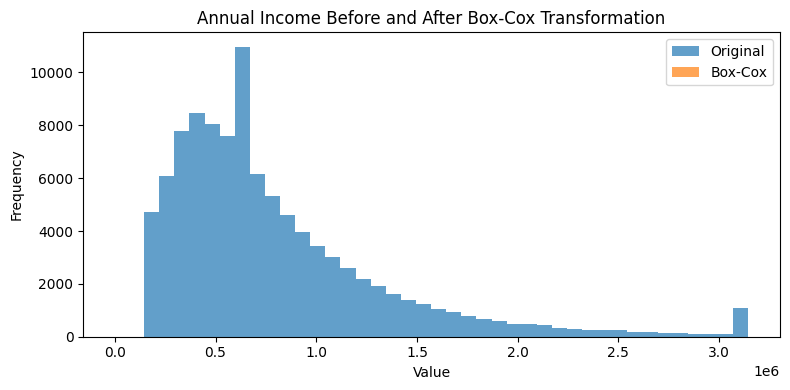

In [91]:
# Compare annual income before and after Box-Cox transformation

plt.figure(figsize=(8, 4))

plt.hist(
    df["annual_income"],
    bins=40,
    alpha=0.7,
    label="Original"
)

plt.hist(
    boxcox_df["annual_income_boxcox"],
    bins=40,
    alpha=0.7,
    label="Box-Cox"
)

plt.title(
    "Annual Income Before and After Box-Cox Transformation"
)
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()
plt.show()

### Transformation Visual Observation

The transformed distribution is on a different numerical scale and is less dominated by the very large income values.

The visual comparison supports the earlier skewness analysis and shows why mathematical transformations can be useful for strongly skewed financial variables.

## 8. Feature Construction — Debt-to-Income Ratio

A customer's loan amount becomes more meaningful when compared with their income.

I will therefore create a Debt-to-Income style ratio using:

`loan_amount / annual_income`

A small protection is included so that a zero income value does not cause a division-by-zero error.

In [92]:
# Create a safe Debt-to-Income ratio

safe_income = df["annual_income"].replace(0, np.nan)

df["debt_to_income_ratio"] = (
    df["loan_amount"] / safe_income
)

# Replace any resulting missing values caused by zero income
df["debt_to_income_ratio"] = (
    df["debt_to_income_ratio"].fillna(0)
)

df[
    [
        "annual_income",
        "loan_amount",
        "debt_to_income_ratio"
    ]
].head()

,annual_income,loan_amount,debt_to_income_ratio
0,655313.00,1817174.27,2.772987
1,609720.06,757269.93,1.241996
2,244292.60,741832.47,3.036656
3,419056.12,1244732.38,2.970324
4,465101.82,2281784.53,4.905989


### Debt-to-Income Observation

The new ratio puts the loan amount into the context of the customer's income.

A higher ratio means the requested loan is large relative to the customer's annual income. This could potentially be useful in a future credit-risk model.

## 9. Feature Construction — Average Monthly Transactions

`transaction_count` represents the total number of transactions during the last six months.

To make the value easier to interpret on a monthly basis, I will create an average monthly transaction feature by dividing the six-month total by six.

In [93]:
# Convert six-month transaction count into an average monthly value

df["average_monthly_transactions"] = (
    df["transaction_count"] / 6
)

df[
    [
        "transaction_count",
        "average_monthly_transactions"
    ]
].head()

,transaction_count,average_monthly_transactions
0,160,26.666667
1,145,24.166667
2,119,19.833333
3,100,16.666667
4,168,28.000000


### Average Monthly Transactions Observation

The new feature converts the six-month transaction count into an approximate monthly average.

This gives a more intuitive measure of customer transaction activity while keeping the original six-month count available for comparison.

## 10. Feature Construction — Spending-to-Income Ratio

The dataset already contains `spending_ratio`, which represents spending relative to income as a percentage.

For the feature-construction requirement, I will create a proportion version of this variable by dividing the percentage by 100.

This keeps the original percentage feature available while providing a ratio on a 0-to-1 scale.

In [94]:
# Convert spending ratio from percentage to proportion

df["spending_to_income_ratio"] = (
    df["spending_ratio"] / 100
)

df[
    [
        "spending_ratio",
        "spending_to_income_ratio"
    ]
].head()

,spending_ratio,spending_to_income_ratio
0,27.29,0.2729
1,14.09,0.1409
2,48.67,0.4867
3,45.55,0.4555
4,41.69,0.4169


### Spending-to-Income Observation

The new feature expresses the existing spending-to-income percentage as a proportion.

For example, a percentage of 40 would become 0.40. This format is often easier to use when constructing mathematical ratios and comparing it with other proportion-based features.

## 11. Feature Construction Check

I have now created the three required constructed features.

Before moving into the final preprocessing pipeline, I want to check that the features contain valid numerical values and that the calculations did not change the number of customer records.

In [95]:
# Check the newly constructed features

constructed_features = [
    "debt_to_income_ratio",
    "average_monthly_transactions",
    "spending_to_income_ratio"
]

print("Constructed features:")
print(constructed_features)

print("\nMissing values:")
print(df[constructed_features].isnull().sum())

print("\nInfinite values:")
print(
    np.isinf(
        df[constructed_features]
    ).sum()
)

print("\nDataset shape:", df.shape)

Constructed features:
['debt_to_income_ratio', 'average_monthly_transactions', 'spending_to_income_ratio']

Missing values:
debt_to_income_ratio            0
average_monthly_transactions    0
spending_to_income_ratio        0
dtype: int64

Infinite values:
debt_to_income_ratio            0
average_monthly_transactions    0
spending_to_income_ratio        0
dtype: int64

Dataset shape: (100000, 41)


### Feature Construction Check

The three constructed features have been created successfully.

I also checked for missing and infinite values because ratio-based features can sometimes create invalid results when the denominator is zero.

The checks confirm that the new features are safe to carry into the final preprocessing stage.

## 12. Preparing the Final ML Feature Set

The demonstrations above were useful for understanding individual preprocessing techniques.

For the final Machine Learning workflow, I do not want to include every demonstration column at the same time. Doing that would create unnecessary duplicate information.

Instead, I will build a clean feature set from the original variables and the three engineered features.

I will also exclude `customer_id` because it is an identifier and exclude `default_flag` because it is the target.

In [96]:
# Define the original predictor columns for the final workflow

final_numeric_features = [
    "age",
    "annual_income",
    "loan_amount",
    "credit_score",
    "repayment_history",
    "transaction_count",
    "spending_ratio",
    "join_year",
    "join_month",
    "join_day",
    "join_weekday",
    "debt_to_income_ratio",
    "average_monthly_transactions",
    "spending_to_income_ratio"
]

final_categorical_features = [
    "gender",
    "region",
    "education_level",
    "employment_type",
    "loan_purpose"
]

final_features = (
    final_numeric_features +
    final_categorical_features
)

X = df[final_features].copy()
y = df["default_flag"].copy()

print("Number of final predictor features:", len(final_features))
print("X shape:", X.shape)
print("y shape:", y.shape)

Number of final predictor features: 19
X shape: (100000, 19)
y shape: (100000,)


### Final Feature Set Observation

The final feature set contains the useful predictive variables without including the customer identifier or target variable.

The individual encoding and transformation demonstrations remain in the notebook as evidence of the required techniques, but they will not all be duplicated in the final ML-ready dataset.

In [97]:
from sklearn.model_selection import train_test_split

# Split before fitting the final preprocessing pipeline

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training data shape: (80000, 19)
Testing data shape: (20000, 19)

Training target distribution:
default_flag
0    0.582
1    0.418
Name: proportion, dtype: float64

Testing target distribution:
default_flag
0    0.582
1    0.418
Name: proportion, dtype: float64


### Train/Test Split Observation

The data has been divided into training and testing sets before fitting the final preprocessing workflow.

I used stratification so that the proportion of default and non-default customers remains similar in both sets.

Most importantly, the preprocessing objects will only learn their parameters from the training data.

## 14. Numerical Preprocessing Pipeline

For the final numerical preprocessing, I will use a simple pipeline.

The financial variables are right-skewed, so I will use Yeo-Johnson as a flexible transformation followed by StandardScaler.

The remaining numerical variables will use median imputation followed by StandardScaler.

Keeping these operations inside a pipeline means that the preprocessing can be fitted consistently using only the training data.

In [98]:
# Numerical feature groups

transformed_numeric_features = [
    "annual_income",
    "loan_amount"
]

regular_numeric_features = [
    "age",
    "credit_score",
    "repayment_history",
    "transaction_count",
    "spending_ratio",
    "join_year",
    "join_month",
    "join_day",
    "join_weekday",
    "debt_to_income_ratio",
    "average_monthly_transactions",
    "spending_to_income_ratio"
]

# Pipeline for skewed financial variables
financial_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "yeo_johnson",
        PowerTransformer(
            method="yeo-johnson"
        )
    ),
    (
        "scaler",
        StandardScaler()
    )
])

# Pipeline for the remaining numerical variables
regular_numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

print("Numerical preprocessing pipelines created successfully.")

Numerical preprocessing pipelines created successfully.


## 15. Categorical Preprocessing

Categorical variables need a different treatment from numerical variables.

For the final ML workflow, I will use the most frequent category for missing categorical values and then apply encoding.

I will use One-Hot Encoding in the final pipeline because it avoids creating an artificial ranking between nominal categories.

The earlier Label Encoding demonstration for `gender` remains in the notebook because it was one of the required techniques.

In [99]:
# Categorical preprocessing pipelines

nominal_categorical_features = [
    "gender",
    "region",
    "employment_type",
    "loan_purpose"
]

education_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "encoder",
        OrdinalEncoder(
            categories=[education_order],
            handle_unknown="use_encoded_value",
            unknown_value=-1
        )
    )
])

nominal_categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    )
])

print("Categorical preprocessing pipelines created successfully.")

Categorical preprocessing pipelines created successfully.


## 16. ColumnTransformer — Combining the Preprocessing Steps

Different columns require different preprocessing methods.

`ColumnTransformer` allows me to apply the numerical pipeline to numerical features and the categorical pipeline to categorical features within one preprocessing object.

This creates a cleaner and more reproducible final preprocessing workflow.

In [100]:
# Combine all preprocessing branches

preprocessor = ColumnTransformer(
    transformers=[
        (
            "financial",
            financial_pipeline,
            transformed_numeric_features
        ),
        (
            "numeric",
            regular_numeric_pipeline,
            regular_numeric_features
        ),
        (
            "education",
            education_pipeline,
            ["education_level"]
        ),
        (
            "categorical",
            nominal_categorical_pipeline,
            nominal_categorical_features
        )
    ],
    remainder="drop"
)

print("ColumnTransformer created successfully.")

ColumnTransformer created successfully.


## 17. Fitting the Final Preprocessor

I will now fit the `ColumnTransformer` using only `X_train`.

The test data will not be used to calculate imputation values, transformation parameters, scaling means or scaling standard deviations.

In [101]:
# Fit the preprocessing workflow only on training data

preprocessor.fit(X_train)

print("Preprocessor fitted using training data only.")

Preprocessor fitted using training data only.


### Preprocessor Fitting Observation

The preprocessing object has now learned its parameters from the training set only.

This is an important part of avoiding data leakage because information from the test set has not been used to fit the transformations.

## 18. Transforming the Training and Testing Data

The preprocessing object is now fitted, so I can use it to transform both datasets.

The same fitted transformations will be applied to the training and testing data.

In [102]:
# Transform training and testing data

X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (80000, 30)
Processed testing shape: (20000, 30)


## 19. Final Encoded Feature Names

After the ColumnTransformer has processed the data, I want to retrieve the resulting feature names.

This makes the final dataset easier to understand and audit.

In [103]:
# Get the final feature names generated by the preprocessor

processed_feature_names = (
    preprocessor.get_feature_names_out()
)

print("Number of processed features:")
print(len(processed_feature_names))

print("\nFirst 20 processed feature names:")
print(processed_feature_names[:20])

Number of processed features:
30

First 20 processed feature names:
['financial__annual_income' 'financial__loan_amount' 'numeric__age'
 'numeric__credit_score' 'numeric__repayment_history'
 'numeric__transaction_count' 'numeric__spending_ratio'
 'numeric__join_year' 'numeric__join_month' 'numeric__join_day'
 'numeric__join_weekday' 'numeric__debt_to_income_ratio'
 'numeric__average_monthly_transactions'
 'numeric__spending_to_income_ratio' 'education__education_level'
 'categorical__gender_Female' 'categorical__gender_Male'
 'categorical__gender_Other' 'categorical__region_East'
 'categorical__region_North']


## 20. Creating the Final ML-Ready Dataset

The preprocessing stage is now complete.

I will convert the processed numerical array back into a Pandas DataFrame so that the final result is easier to inspect and export.

The target variable will then be added separately.

`customer_id` is intentionally not included as a predictive feature.

In [104]:
# Convert the processed training and testing arrays into DataFrames

X_train_processed_df = pd.DataFrame(
    X_train_processed,
    columns=processed_feature_names,
    index=X_train.index
)

X_test_processed_df = pd.DataFrame(
    X_test_processed,
    columns=processed_feature_names,
    index=X_test.index
)

# Add the target back after preprocessing

train_ml_ready = X_train_processed_df.copy()
train_ml_ready["default_flag"] = y_train

test_ml_ready = X_test_processed_df.copy()
test_ml_ready["default_flag"] = y_test

print("Training ML-ready dataset:", train_ml_ready.shape)
print("Testing ML-ready dataset:", test_ml_ready.shape)

train_ml_ready.head()

Training ML-ready dataset: (80000, 31)
Testing ML-ready dataset: (20000, 31)


,financial__annual_income,financial__loan_amount,numeric__age,numeric__credit_score,numeric__repayment_history,numeric__transaction_count,numeric__spending_ratio,numeric__join_year,numeric__join_month,numeric__join_day,...,categorical__region_West,categorical__employment_type_Salaried,categorical__employment_type_Self-Employed,categorical__employment_type_Unemployed,categorical__loan_purpose_Business,categorical__loan_purpose_Car,categorical__loan_purpose_Education,categorical__loan_purpose_Home,categorical__loan_purpose_Other,default_flag
26457,-0.290526,-1.743902,-0.096859,0.635756,1.612577,1.893740,-1.799591,0.531713,0.139360,0.373486,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0
74957,-0.150378,0.312595,1.185777,0.755714,1.612577,-0.459147,-1.522437,-1.558936,-0.734895,-0.080207,...,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0
81323,-2.264723,-0.877142,0.495127,-0.827823,-0.197439,-0.341502,0.699593,-1.558936,0.430778,1.167448,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1
78825,1.004215,-0.549950,0.396463,-2.038123,-1.102447,-1.086583,0.272669,1.228596,-0.152058,-1.101016,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0
98369,-0.833278,-1.366923,-0.096859,-0.002569,1.612577,1.187874,-0.509758,1.228596,-0.734895,-0.080207,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0


## 21. Final ML-Ready Dataset Validation

Before exporting the processed data, I want to perform a final quality check.

I will verify:

- Missing values
- Duplicate rows
- Data types
- Target definition
- Number of rows
- Infinite values
- Presence of the customer identifier

These checks are important because a dataset can look clean while still containing values that would cause problems during Machine Learning.

In [105]:
# Final validation of the training ML-ready dataset

print("===== FINAL ML-READY DATASET AUDIT =====")

print("\nShape:")
print(train_ml_ready.shape)

print("\nMissing values:")
print(train_ml_ready.isnull().sum().sum())

print("\nDuplicate rows:")
print(train_ml_ready.duplicated().sum())

print("\nInfinite values:")
print(
    np.isinf(
        train_ml_ready.select_dtypes(include=np.number)
    ).sum().sum()
)

print("\nAll columns numeric:")
print(
    train_ml_ready.dtypes.apply(
        lambda dtype: np.issubdtype(dtype, np.number)
    ).all()
)

print("\nTarget values:")
print(
    train_ml_ready["default_flag"]
    .value_counts()
    .sort_index()
)

print("\nCustomer ID included:")
print(
    any(
        "customer_id" in column.lower()
        for column in train_ml_ready.columns
    )
)

===== FINAL ML-READY DATASET AUDIT =====

Shape:
(80000, 31)

Missing values:
0

Duplicate rows:


0

Infinite values:
0

All columns numeric:
True

Target values:
default_flag
0    46552
1    33448
Name: count, dtype: int64

Customer ID included:
False


### Final ML-Ready Validation Observation

The final processed training dataset contains numerical features suitable for Machine Learning.

The customer identifier has not been used as a predictive feature, and the target variable has remained separate from the preprocessing transformations.

The final checks also confirm that missing, duplicate and infinite values are not present in the processed data.

## 22. Data Leakage Check

A final check is useful because preprocessing can accidentally introduce data leakage.

In this workflow:

1. The data was split into training and testing sets first.
2. The `ColumnTransformer` was fitted only on `X_train`.
3. `X_test` was transformed using the already-fitted preprocessor.
4. `default_flag` was not used to create predictive features.
5. `customer_id` was excluded from the final feature set.

This keeps the final preprocessing workflow separate from the test information.

In [106]:
# Explicit leakage-prevention checks

leakage_checks = {
    "Target excluded from X before preprocessing":
        "default_flag" not in X.columns,

    "Customer ID excluded from X":
        "customer_id" not in X.columns,

    "Preprocessor fitted before test transformation":
        hasattr(preprocessor, "transformers_"),

    "Train/test feature counts match":
        X_train_processed.shape[1] == X_test_processed.shape[1]
}

leakage_check_df = pd.DataFrame(
    list(leakage_checks.items()),
    columns=["Check", "Passed"]
)

leakage_check_df

,Check,Passed
0,Target excluded from X before preprocessing,True
1,Customer ID excluded from X,True
2,Preprocessor fitted before test transformation,True
3,Train/test feature counts match,True


### Leakage Check Observation

The final preprocessing workflow follows the intended train/test separation.

The target was excluded from the predictors, the customer identifier was excluded, and the same fitted preprocessing structure was used for both training and testing data.

This makes the final workflow suitable for use before a future Machine Learning model.

## 23. Exporting the Final Datasets

The preprocessing work is now complete, so I will save the results as CSV files.

I will keep one cleaned and engineered dataset for reference and one final ML-ready dataset for future modelling.

Saving both versions makes it easier to understand the difference between the cleaned business dataset and the numerical dataset that can be passed to a Machine Learning algorithm.

In [107]:
# Save the cleaned and engineered dataset

cleaned_dataset_path = "customer_credit_risk_cleaned_engineered.csv"

df.to_csv(
    cleaned_dataset_path,
    index=False
)

# Combine the processed training and testing data
# to create a complete transformed dataset.

final_ml_ready = pd.concat(
    [
        train_ml_ready,
        test_ml_ready
    ],
    axis=0
).sort_index()

final_ml_ready_path = "customer_credit_risk_ml_ready.csv"

final_ml_ready.to_csv(
    final_ml_ready_path,
    index=False
)

print("Files exported successfully.")

print("\nCleaned dataset:")
print(cleaned_dataset_path)

print("\nML-ready dataset:")
print(final_ml_ready_path)

print("\nFinal ML-ready shape:")
print(final_ml_ready.shape)

Files exported successfully.

Cleaned dataset:
customer_credit_risk_cleaned_engineered.csv

ML-ready dataset:
customer_credit_risk_ml_ready.csv

Final ML-ready shape:
(100000, 31)


## 24. Final Target Distribution

The target variable is the variable that the future Machine Learning model will attempt to predict.

I will make one final check to confirm that `default_flag` is still binary and has not been altered by preprocessing.

Final target values:
default_flag
0    58190
1    41810
Name: count, dtype: int64

Unique target values:
[np.int64(0), np.int64(1)]


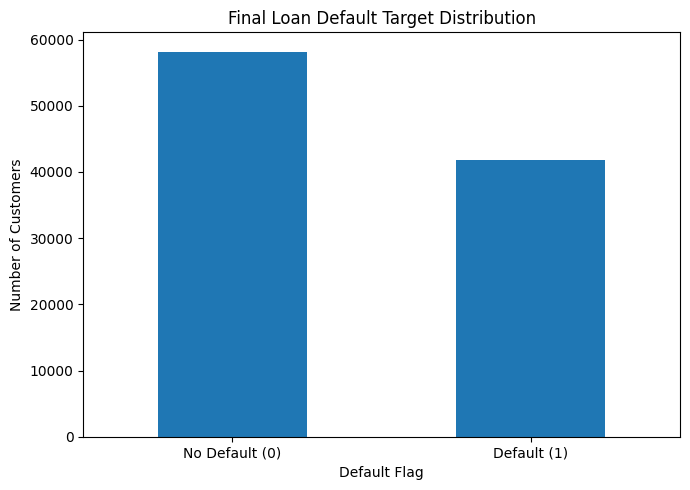

In [108]:
# Final target validation

target_check = final_ml_ready["default_flag"].value_counts().sort_index()

print("Final target values:")
print(target_check)

print("\nUnique target values:")
print(
    sorted(
        final_ml_ready["default_flag"].unique()
    )
)

# Final target distribution chart

plt.figure(figsize=(7, 5))

target_check.plot(kind="bar")

plt.title("Final Loan Default Target Distribution")
plt.xlabel("Default Flag")
plt.ylabel("Number of Customers")
plt.xticks(
    [0, 1],
    ["No Default (0)", "Default (1)"],
    rotation=0
)

plt.tight_layout()
plt.show()

### Final Target Observation

The final dataset still contains the original binary target definition:

- `0` represents no default.
- `1` represents default.

The target was kept outside the preprocessing transformations and added back only after the predictor features had been processed.

# PART H — FINAL DELIVERABLE & PROJECT AUDIT

The preprocessing workflow is now complete.

Before considering the project finished, I will perform one final audit against the project requirements.

The purpose of this audit is to make sure the final dataset is clean, numerical, consistently processed and suitable for future Machine Learning modelling.

In [109]:
# ============================================================
# FINAL PROJECT AUDIT
# ============================================================

final_audit = {}

# 1. Shape
final_audit["Rows preserved"] = (
    len(final_ml_ready) == len(df)
)

# 2. Missing values
final_audit["No missing values"] = (
    final_ml_ready.isnull().sum().sum() == 0
)

# 3. Duplicate rows
final_audit["No duplicate rows"] = (
    final_ml_ready.duplicated().sum() == 0
)

# 4. All predictor columns numeric
predictor_columns = [
    column
    for column in final_ml_ready.columns
    if column != "default_flag"
]

final_audit["All predictors numeric"] = (
    final_ml_ready[predictor_columns]
    .dtypes
    .apply(
        lambda dtype: np.issubdtype(dtype, np.number)
    )
    .all()
)

# 5. Target exists
final_audit["Target exists"] = (
    "default_flag" in final_ml_ready.columns
)

# 6. Target is binary
final_audit["Target is binary"] = (
    set(
        final_ml_ready["default_flag"].unique()
    ).issubset({0, 1})
)

# 7. Customer ID excluded
final_audit["customer_id excluded"] = (
    not any(
        "customer_id" in column.lower()
        for column in final_ml_ready.columns
    )
)

# 8. No infinite values
final_audit["No infinite values"] = (
    np.isinf(
        final_ml_ready
        .select_dtypes(include=np.number)
    ).sum().sum() == 0
)

# Display audit
final_audit_df = pd.DataFrame({
    "Requirement": list(final_audit.keys()),
    "Passed": list(final_audit.values())
})

final_audit_df

,Requirement,Passed
0,Rows preserved,True
1,No missing values,True
2,No duplicate rows,True
3,All predictors numeric,True
4,Target exists,True
5,Target is binary,True
6,customer_id excluded,True
7,No infinite values,True


### Final Dataset Shape and ML Readiness

The cleaned and engineered dataset contains 100,000 rows and 41 columns.

After the final preprocessing and encoding pipeline, the ML-ready dataset contains 100,000 rows and 31 columns.

The final ML-ready dataset contains numerical predictor features and the `default_flag` target variable. The `customer_id` identifier has been excluded from the predictive features.

The final validation checks confirm that the dataset contains no missing values, duplicate rows or infinite numerical values.

This makes the final dataset suitable as an input dataset for a future Machine Learning classification model.

## Final Project Summary

This project took the Customer Credit Risk dataset through a complete data-preparation workflow.

### Missing Values

I first identified missing values and compared several approaches, including mean/median imputation, categorical imputation, random-sample imputation, KNN imputation, Iterative Imputation and Complete Case Analysis.

For the final working dataset, I used simple and explainable imputation methods while keeping the more advanced approaches as demonstrations.

### Outlier Handling

I compared Z-score, IQR and percentile methods for detecting outliers.

Winsorization was then used for the final outlier treatment so that extreme values were capped rather than removing customer records.

### Encoding

Different encoding techniques were demonstrated according to the type of variable:

- Ordinal Encoding for `education_level`
- Label Encoding for `gender`
- One-Hot Encoding for `region`
- One-Hot Encoding for `loan_purpose`

### Scaling

I demonstrated:

- StandardScaler
- Min-Max Scaling
- Normalization
- MaxAbs Scaling
- Robust Scaling

The final preprocessing workflow uses StandardScaler after the appropriate numerical preprocessing.

### Transformations

I demonstrated:

- Log transformation
- Reciprocal transformation
- Square-root transformation
- Box-Cox transformation
- Yeo-Johnson transformation

The transformations were investigated based on the distribution of the numerical variables rather than being applied blindly.

### Feature Construction

Three additional features were constructed:

- Debt-to-Income ratio
- Average monthly transactions
- Spending-to-Income ratio

These features provide additional ways of representing customer financial behaviour.

### Final Preprocessing

The final workflow uses `ColumnTransformer` to apply different preprocessing steps to numerical and categorical variables.

The preprocessing object was fitted using training data only before transforming the test data. This helps prevent data leakage.

### Final Result

The final dataset contains numerical features that can be passed to a future Machine Learning model.

The target variable remains `default_flag`, where:

- `0` = No Default
- `1` = Default

The customer identifier was intentionally excluded from the predictive feature set.

# REFERENCES & CREDIT

The following resources were consulted while developing the preprocessing workflow in this notebook.

### Python Libraries and Documentation

1. **Pandas Documentation**  
   Used for DataFrame creation, data loading, inspection, descriptive statistics, missing-value analysis and CSV export.

2. **NumPy Documentation**  
   Used for numerical arrays, mathematical transformations, random-number generation and numerical calculations.

3. **SciPy Documentation**  
   Used for statistical operations including Z-score analysis and winsorization.

4. **Scikit-learn Documentation**  
   Used for:
   - SimpleImputer
   - KNNImputer
   - IterativeImputer
   - LabelEncoder
   - OrdinalEncoder
   - OneHotEncoder
   - KBinsDiscretizer
   - Binarizer
   - StandardScaler
   - MinMaxScaler
   - MaxAbsScaler
   - RobustScaler
   - Normalizer
   - FunctionTransformer
   - PowerTransformer
   - ColumnTransformer
   - Pipeline
   - train_test_split

### Project Material

5. **Holistic Data Preparer (Final Project) — Red & White Skill Education**  
   Used as the main project brief, including the dataset structure, required preprocessing tasks, feature-engineering requirements and submission criteria.

### Dataset Credit

6. **Customer Credit Risk Dataset**  
   The dataset used in this project is synthetic data generated for educational purposes using Python-based random data generation. It does not represent real customer records.

7. **AI-Assisted Dataset Design**  
   AI assistance was used during the planning/design of the synthetic dataset structure and project workflow. The preprocessing code in this notebook was implemented and reviewed as part of the project workflow.

### Important Note

All transformations, preprocessing decisions and final feature construction were applied specifically to the synthetic Customer Credit Risk dataset used in this educational project.